GGSN ćwiczenia labolaroryjne  - Dane Tabelaryczne

Anna Moroń

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import subprocess
from IPython import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

Data source: https://www.kaggle.com/datasets/sehaj1104/student-placement-prediction-dataset-2026

In [2]:
df = pd.read_csv('data/archive/student_placement_prediction_dataset_2026.csv')
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [3]:
rows = []
for col in df.columns:
    dtype      = df[col].dtype
    missing    = df[col].isna().sum()

    if pd.api.types.is_string_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col]):
        n_unique   = df[col].nunique()
        top_values = df[col].value_counts().head(5).to_dict()
        top_str    = " / ".join(f"{k}: {v}" for k, v in top_values.items())
    else:
        n_unique  = df[col].nunique()
        top_str   = f"min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f} "

    rows.append({
        "Column"        : col,
        "Dtype"         : str(dtype),
        "Missing"       : missing,
        "Unique Values" : n_unique,
        "Details"       : top_str,
    })

results_df = pd.DataFrame(rows)

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows",     100)

print("  DATASET OVERVIEW")
print(f"  Rows: {len(df):,}   |   Columns: {len(df.columns)}")

display.display(results_df)


  DATASET OVERVIEW
  Rows: 100,000   |   Columns: 26


,Column,Dtype,Missing,Unique Values,Details
0,student_id,int64,0,100000,"min=1, max=100000, mean=50000.50"
1,age,int64,0,7,"min=18, max=24, mean=21.01"
2,gender,str,0,2,Male: 60028 / Female: 39972
3,cgpa,float64,0,551,"min=4.5, max=10.0, mean=7.50"
4,branch,str,0,6,CSE: 34818 / IT: 19999 / ECE: 14908 / EEE: 10177 / Mechanical: 10077
5,college_tier,str,0,3,Tier 2: 49955 / Tier 3: 29884 / Tier 1: 20161
6,internships_count,int64,0,9,"min=0, max=8, mean=1.50"
7,projects_count,int64,0,14,"min=0, max=13, mean=3.00"
8,certifications_count,int64,0,12,"min=0, max=11, mean=2.01"
9,coding_skill_score,float64,0,97643,"min=20.0, max=100.0, mean=69.83"


In [4]:
print("Changing dtypes and encoding categorical variables...\n")

encoding_maps = {
    "gender"              : {"Male": 0, "Female": 1},
    "volunteer_experience": {"No": 0, "Yes": 1},
    "placement_status"    : {"Not Placed": 0, "Placed": 1},
    "college_tier"        : {"Tier 1": 3, "Tier 2": 2, "Tier 3": 1},
}
 
for col, mapping in encoding_maps.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f"[encoded]  {col:30s} → {mapping}")

remaining_cat = [
    c for c in df.columns
    if pd.api.types.is_string_dtype(df[c]) and not pd.api.types.is_bool_dtype(df[c])
]
 
if remaining_cat:
    print(f"\n[one-hot]  {remaining_cat}")
    df = pd.get_dummies(df, columns=remaining_cat, drop_first=True)


Changing dtypes and encoding categorical variables...

[encoded]  gender                         → {'Male': 0, 'Female': 1}
[encoded]  volunteer_experience           → {'No': 0, 'Yes': 1}
[encoded]  placement_status               → {'Not Placed': 0, 'Placed': 1}
[encoded]  college_tier                   → {'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1}

[one-hot]  ['branch']


In [5]:
df['academic_strength']   = df['cgpa'] * df['coding_skill_score'] / 100
df['experience_score']    = df['internships_count'] * 2 + df['projects_count']
df['has_backlogs']        = (df['backlogs'] > 0).astype(int)
df['skills_avg']          = df[['coding_skill_score','aptitude_score',
                                 'communication_skill_score','logical_reasoning_score']].mean(axis=1)

df_model = df.drop(columns=["student_id", "cgpa", "coding_skill_score", "internships_count", "projects_count", "backlogs", "coding_skill_score",
                            "aptitude_score", "communication_skill_score", "logical_reasoning_score"])

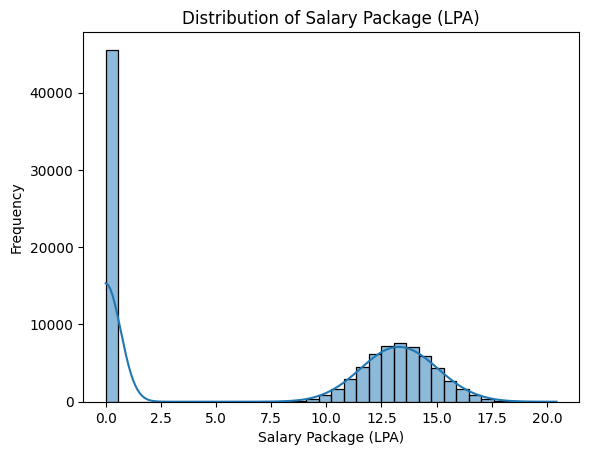

In [26]:
sns.histplot(df['salary_package_lpa'], kde=True)
plt.title('Distribution of Salary Package (LPA)')
plt.xlabel('Salary Package (LPA)')
plt.ylabel('Frequency')
plt.show()

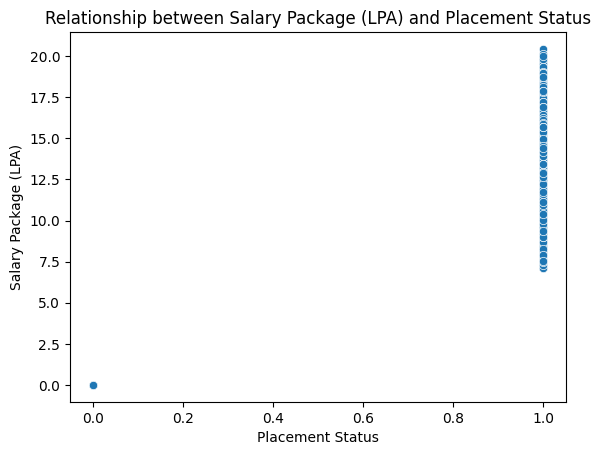

In [27]:
# korelacja salary_package_lpa z innych kolumn
sns.scatterplot(x='placement_status', y='salary_package_lpa', data=df)
plt.title('Relationship between Salary Package (LPA) and Placement Status')
plt.xlabel('Placement Status')
plt.ylabel('Salary Package (LPA)')
plt.show()

### Załorzenia

Przewidywaną kolumną będzie:
- salary_package_lpa - o wartościach float64 - watrość odpowiada wysokości zarobków studenta, jest równa zero jeśli student nie jest zatrudniony, dla zatrudnionych studentów (60% rekordów) kolumna może być targetem regresji.

Zostanie wykonana regresja przy użyciu:
- Random Forest
- SVM
- XGBoost
- TabNet
- ANN - razem z step-by-step optymalizacją hiperparametrów w kilku kolejnościach.

## Regresja

In [64]:
# 2. REGRESJA — target: salary_package_lpa (float)
#    Tylko studenci zatrudnieni (placement_status == 1), bez kolumny placement_status

df_reg = df_model[df_model["placement_status"] == 1].drop(columns=["placement_status"])

X_reg = df_reg.drop(columns=["salary_package_lpa"])
y_reg = df_reg["salary_package_lpa"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg,
    test_size=0.3,
    random_state=42
)

print("\n── REGRESJA ─────────────────────────────────────────")
print(f"  Rekordy po filtrze salary > 0: {len(df_reg):,}  ({len(df_reg)/len(df_model):.1%} całości)")
print(f"  Train: {X_reg_train.shape}  |  Test: {X_reg_test.shape}")
print(f"  Salary — min: {y_reg.min():.2f}  max: {y_reg.max():.2f}  mean: {y_reg.mean():.2f}  median: {y_reg.median():.2f}")


── REGRESJA ─────────────────────────────────────────
  Rekordy po filtrze salary > 0: 54,459  (54.5% całości)
  Train: (38121, 23)  |  Test: (16338, 23)
  Salary — min: 7.11  max: 20.44  mean: 13.32  median: 13.30


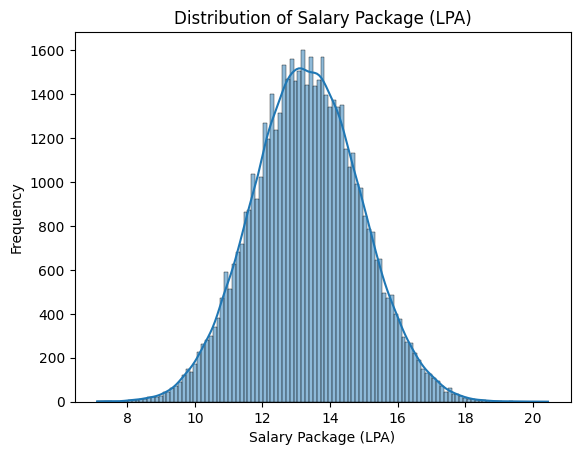

In [100]:
sns.histplot(df_reg['salary_package_lpa'], kde=True)
plt.title('Distribution of Salary Package (LPA)')
plt.xlabel('Salary Package (LPA)')
plt.ylabel('Frequency')
plt.show()

In [65]:
scaler_reg = StandardScaler()
X_reg_train = pd.DataFrame(scaler_reg.fit_transform(X_reg_train), columns=X_reg_train.columns)
X_reg_test  = pd.DataFrame(scaler_reg.transform(X_reg_test),  columns=X_reg_test.columns)

# Podział test → val/test (tak jak w klasyfikacji)
X_reg_val, X_reg_test, y_reg_val, y_reg_test = train_test_split(
    X_reg_test, y_reg_test, test_size=0.5, random_state=2
)

In [102]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.layers import BatchNormalization

In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from pytorch_tabnet.tab_model import TabNetRegressor

models_reg = {
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),
    "SVM": SVR(
        kernel='rbf',
        C=1,
        gamma='scale'
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5
    ),
}

results_reg = {}
for name, model in models_reg.items():
    model.fit(X_reg_train, y_reg_train)
    y_pred = model.predict(X_reg_test)
    results_reg[name] = {
        "MAE":  mean_absolute_error(y_reg_test, y_pred),
        "RMSE": root_mean_squared_error(y_reg_test, y_pred),
        "R²":   r2_score(y_reg_test, y_pred)
    }

In [92]:
X_reg_train_tn = X_reg_train.astype(float).values.astype("float32")
X_reg_test_tn  = X_reg_test.astype(float).values.astype("float32")
y_reg_train_tn = y_reg_train.values.reshape(-1, 1).astype("float32")
y_reg_test_tn  = y_reg_test.values.reshape(-1, 1).astype("float32")

tabnet_reg = TabNetRegressor()
tabnet_reg.fit(
    X_reg_train_tn, y_reg_train_tn,
    eval_set=[(X_reg_test_tn, y_reg_test_tn)],
    eval_metric=["mae"],
    max_epochs=50
)

y_pred_tabnet = tabnet_reg.predict(X_reg_test_tn).flatten()
results_reg["TabNet"] = {
    "MAE":  mean_absolute_error(y_reg_test, y_pred_tabnet),
    "RMSE": root_mean_squared_error(y_reg_test, y_pred_tabnet),
    "R²":   r2_score(y_reg_test, y_pred_tabnet)
}

/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 302: Error loading CUDA libraries. GPU will not be used. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/.venv/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 39.22944| val_0_mae: 1.76402 |  0:00:04s
epoch 1  | loss: 2.34177 | val_0_mae: 1.12844 |  0:00:08s
epoch 2  | loss: 1.62394 | val_0_mae: 1.01757 |  0:00:10s
epoch 3  | loss: 1.51201 | val_0_mae: 0.94969 |  0:00:11s
epoch 4  | loss: 1.43384 | val_0_mae: 0.92979 |  0:00:13s
epoch 5  | loss: 1.36647 | val_0_mae: 0.91049 |  0:00:15s
epoch 6  | loss: 1.32474 | val_0_mae: 0.90869 |  0:00:17s
epoch 7  | loss: 1.31261 | val_0_mae: 0.89468 |  0:00:18s
epoch 8  | loss: 1.2924  | val_0_mae: 0.90094 |  0:00:20s
epoch 9  | loss: 1.31194 | val_0_mae: 0.8948  |  0:00:22s
epoch 10 | loss: 1.31268 | val_0_mae: 0.90147 |  0:00:23s
epoch 11 | loss: 1.29315 | val_0_mae: 0.89981 |  0:00:25s
epoch 12 | loss: 1.27673 | val_0_mae: 0.88768 |  0:00:27s
epoch 13 | loss: 1.27108 | val_0_mae: 0.89148 |  0:00:30s
epoch 14 | loss: 1.27026 | val_0_mae: 0.88643 |  0:00:33s
epoch 15 | loss: 1.27197 | val_0_mae: 0.89526 |  0:00:35s
epoch 16 | loss: 1.27355 | val_0_mae: 0.88667 |  0:00:36s
epoch 17 | los

/.venv/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [94]:
print(pd.DataFrame(results_reg).T)

                   MAE      RMSE        R²
RandomForest  0.885636  1.108745  0.520275
SVM           0.905041  1.129330  0.502296
XGBoost       0.880116  1.101816  0.526252
TabNet        0.880964  1.102334  0.525807


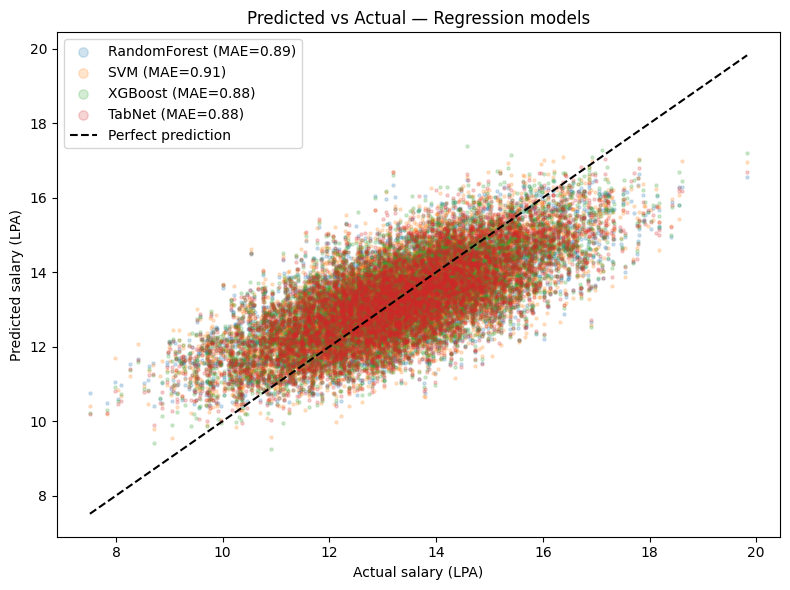

In [96]:
# Zbierz predykcje wszystkich modeli
y_pred_dict = {}
for name, model in models_reg.items():
    y_pred_dict[name] = model.predict(X_reg_test)
y_pred_dict["TabNet"] = tabnet_reg.predict(X_reg_test_tn).flatten()

# Predicted vs Actual plot
plt.figure(figsize=(8, 6))

for name, y_pred in y_pred_dict.items():
    mae = mean_absolute_error(y_reg_test, y_pred)
    plt.scatter(y_reg_test, y_pred, alpha=0.2, s=5, label=f"{name} (MAE={mae:.2f})")

# Linia idealna (perfect predictions)
min_val = y_reg_test.min()
max_val = y_reg_test.max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label="Perfect prediction")

plt.xlabel("Actual salary (LPA)")
plt.ylabel("Predicted salary (LPA)")
plt.title("Predicted vs Actual — Regression models")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

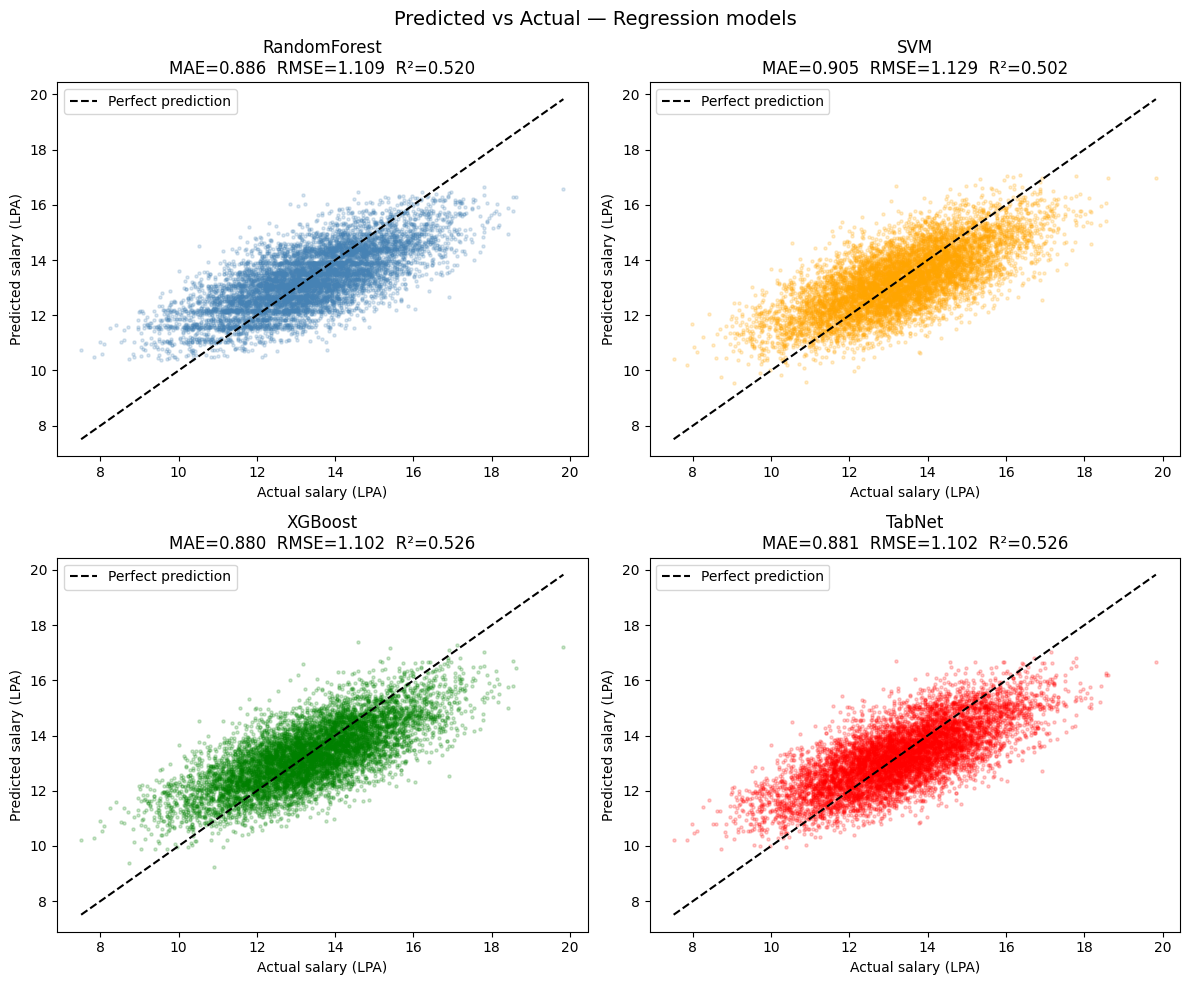

In [99]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colors = ['steelblue', 'orange', 'green', 'red']

for idx, (name, y_pred) in enumerate(y_pred_dict.items()):
    mae  = mean_absolute_error(y_reg_test, y_pred)
    rmse = root_mean_squared_error(y_reg_test, y_pred)
    r2   = r2_score(y_reg_test, y_pred)

    axes[idx].scatter(y_reg_test, y_pred, alpha=0.2, s=5, color=colors[idx])

    min_val = y_reg_test.min()
    max_val = y_reg_test.max()
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'k--', label="Perfect prediction")

    axes[idx].set_title(f"{name}\nMAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")
    axes[idx].set_xlabel("Actual salary (LPA)")
    axes[idx].set_ylabel("Predicted salary (LPA)")
    axes[idx].legend()

plt.suptitle("Predicted vs Actual — Regression models", fontsize=14)
plt.tight_layout()
plt.show()

Obserwujemy bardzo zbilżone wyniki dla poszczególnych klasyfikatorów

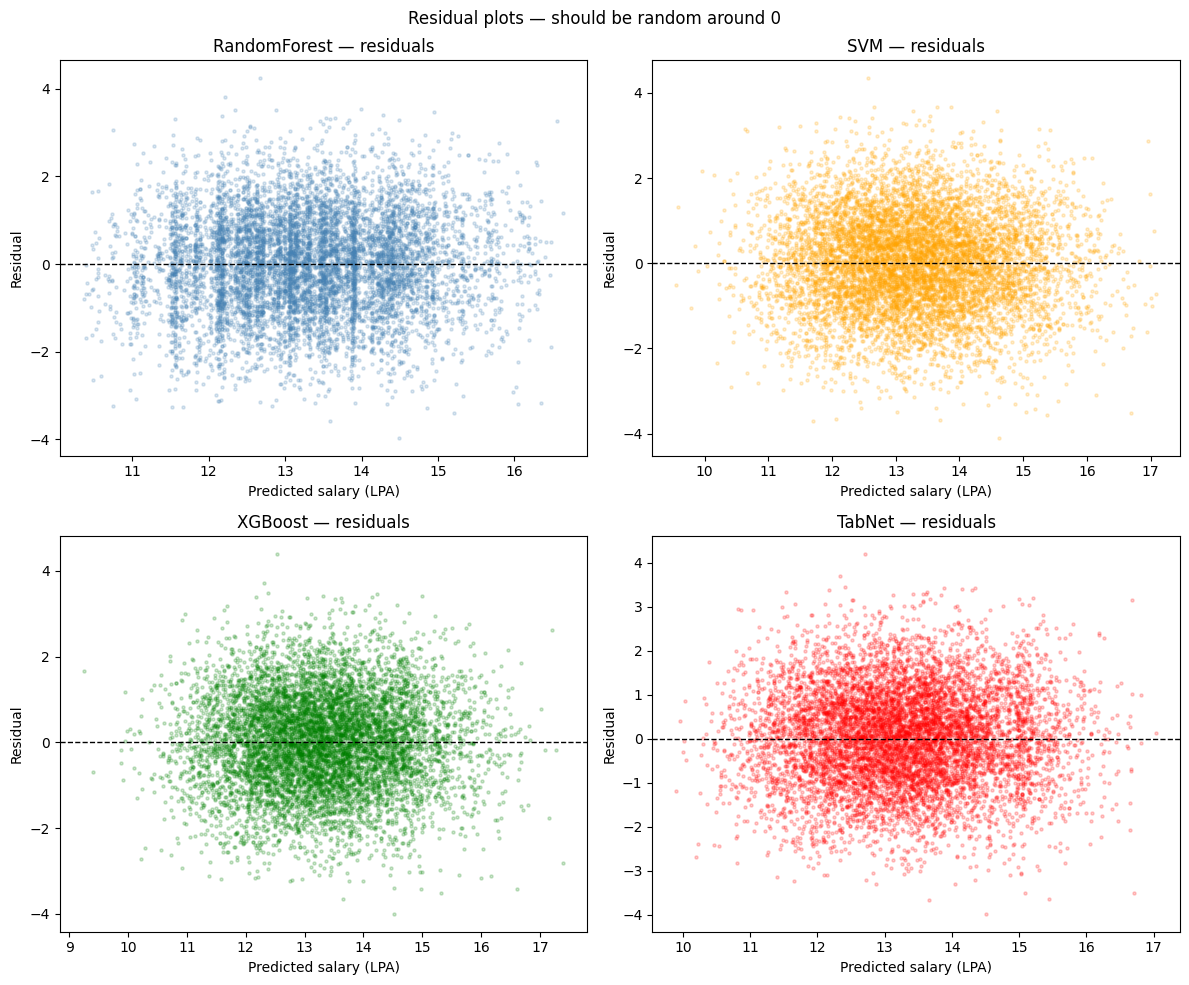

In [112]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
colors = ['steelblue', 'orange', 'green', 'red']

for idx, (name, y_pred) in enumerate(y_pred_dict.items()):
    residuals = y_reg_test - y_pred
    axes[idx].scatter(y_pred, residuals, alpha=0.2, s=5, color=colors[idx])
    axes[idx].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[idx].set_xlabel('Predicted salary (LPA)')
    axes[idx].set_ylabel('Residual')
    axes[idx].set_title(f'{name} — residuals')

plt.suptitle('Residual plots — should be random around 0')
plt.tight_layout()
plt.show()

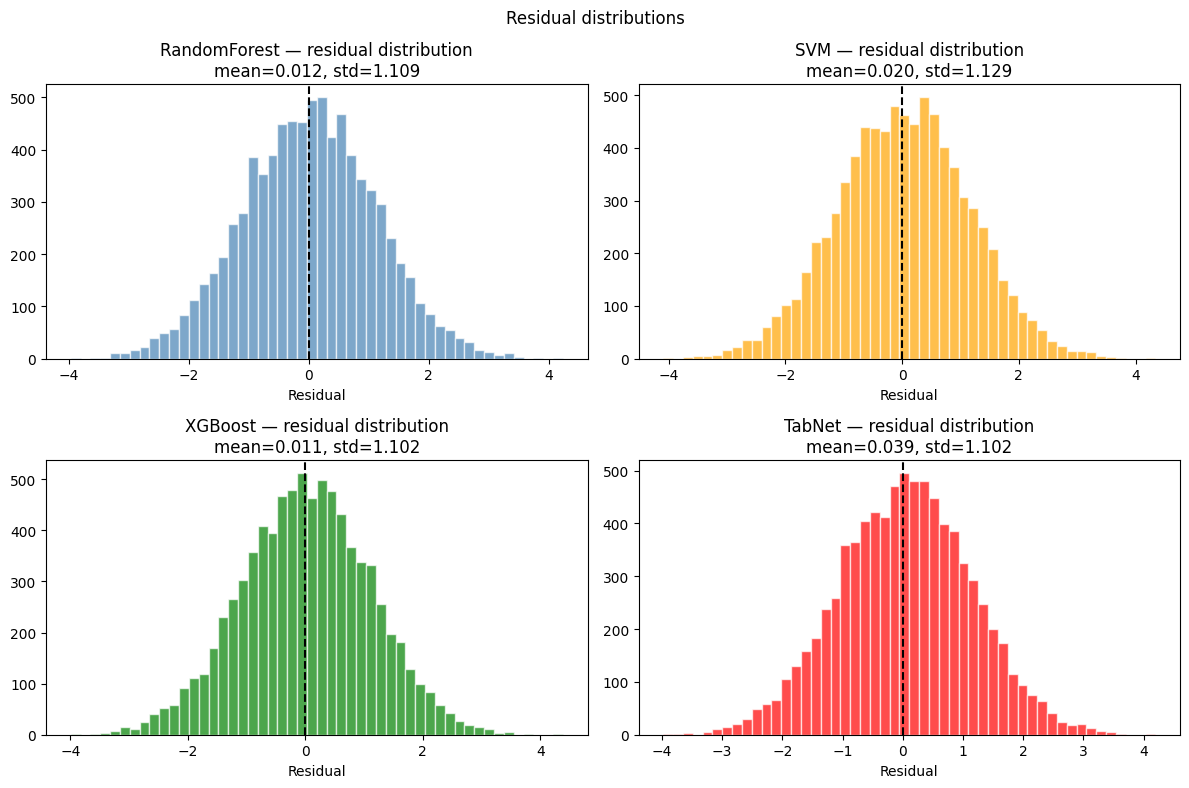

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for idx, (name, y_pred) in enumerate(y_pred_dict.items()):
    residuals = y_reg_test - y_pred
    axes[idx].hist(residuals, bins=50, color=colors[idx], alpha=0.7, edgecolor='white')
    axes[idx].axvline(0, color='black', linestyle='--')
    axes[idx].set_title(f'{name} — residual distribution\nmean={residuals.mean():.3f}, std={residuals.std():.3f}')
    axes[idx].set_xlabel('Residual')
plt.suptitle('Residual distributions')
plt.tight_layout()
plt.show()

Obserwujemy rozkłady zbilżone do rozkładu normalnego.

In [67]:
def build_and_train_regression(neurons=64, layers=2, activation='relu', dropout_rate=0.2,
                                optimizer='adam', learning_rate=0.001, batch_size=32,
                                regularization=None, batch_norm=False):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(X_reg_train.shape[1],),
                    kernel_regularizer=regularization))
    if batch_norm:
        model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    for _ in range(layers - 1):
        model.add(Dense(neurons, activation=activation, kernel_regularizer=regularization))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='linear'))



    if optimizer == "adam":
        opt = keras.optimizers.Adam(learning_rate)
    elif optimizer == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate)
    else:
        opt = keras.optimizers.SGD(learning_rate)

    model.compile(optimizer=opt, loss='mse', metrics=['mae'])

    history = model.fit(X_reg_train, y_reg_train, epochs=50, batch_size=batch_size,
                        validation_data=(X_reg_val, y_reg_val), verbose=0)

    val_mae = min(history.history['val_mae'])
    return model, val_mae, history

In [68]:
import matplotlib.pyplot as plt
import random
random.seed(42)

def optimize_hyperparameter_reg(param_name, candidate_values, best_params, build_and_train_model,
                            X_val, y_val, X_test, y_test, verbose=True):
    results = []          # List to store tuples: (candidate, test_acc, train_acc, train_loss, val_acc, val_loss)
    candidate_labels = [] # For plotting (string version of candidate)
    train_accs = []       # Training accuracy per candidate
    train_losses = []     # Training loss per candidate
    val_accs = []         # Validation accuracy per candidate
    val_losses = []       # Validation loss per candidate

    for candidate in candidate_values:
        # Remove the parameter to be optimized from a copy of best_params.
        params = best_params.copy()
        params.pop(param_name, None)
        
        # Build and train the model with the candidate value.
        # Assume build_and_train_model returns (model, train_acc, history)
        model, train_acc, history = build_and_train_model(**{param_name: candidate}, **params)
        # Retrieve the final training loss from the history
        train_loss = history.history['loss'][-1]
        train_mae = history.history['mae'][-1]
        # Evaluate on validation set.
        val_mse, val_mae = model.evaluate(X_val, y_val, verbose=0)
        test_mse, test_mae = model.evaluate(X_test, y_test, verbose=0)
        
        if verbose:
            print(f"Candidate {candidate}: train_mae = {train_mae:.4f}, train_loss = {train_loss:.4f}, "
                  f"val_mae = {val_mae:.4f}, val_mse = {val_mse:.4f}, test_mae = {test_mae:.4f}")
        
        results.append((candidate, test_mae, train_mae, train_loss, val_mae, val_mse))
        candidate_labels.append(str(candidate))
        train_accs.append(train_mae)
        train_losses.append(train_loss)
        val_accs.append(val_mae)
        val_losses.append(val_mse)
    
    # Create a chart with two subplots: one for accuracy and one for loss.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x = range(len(candidate_values))
    width = 0.35  # Width for grouped bars

    # Plot training and validation accuracy.
    ax1.bar([xi - width/2 for xi in x], train_accs, width=width, label="Train MAE")
    ax1.bar([xi + width/2 for xi in x], val_accs, width=width, label="Val MAE", color='green')
    ax1.set_xticks(x)
    ax1.set_xticklabels(candidate_labels)
    ax1.set_title(f"{param_name} - MAE (Train vs. Val)")
    ax1.set_xlabel(param_name)
    ax1.set_ylabel("MAE")
    ax1.legend()

    # Plot training and validation loss.
    ax2.bar([xi - width/2 for xi in x], train_losses, width=width, label="Train Loss")
    ax2.bar([xi + width/2 for xi in x], val_losses, width=width, label="Val Loss", color='orange')
    ax2.set_xticks(x)
    ax2.set_xticklabels(candidate_labels)
    ax2.set_title(f"{param_name} - Loss (Train vs. Val)")
    ax2.set_xlabel(param_name)
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.suptitle(f"Optimization of {param_name}")
    plt.show()

    best_value = min(results, key=lambda x: x[4])[0]
    best_params[param_name] = best_value
    print(f"Best {param_name}: {best_value}")
    return best_params

In [69]:
import matplotlib.pyplot as plt
from keras import regularizers

def optimize_regularization_reg(reg_candidates, best_params, build_and_train_model, 
                            X_val, y_val, X_test, y_test, verbose=True):

    results = []          # Will store tuples: (reg_id, reg_obj, test_acc, train_acc, train_loss, val_acc, val_loss)
    candidate_labels = [] # For plotting: candidate identifiers
    train_accs = []       # Training accuracy for each candidate
    train_losses = []     # Training loss for each candidate
    val_accs = []         # Validation accuracy for each candidate
    val_losses = []       # Validation loss for each candidate

    for reg_id, reg_obj in reg_candidates:
        # Create a copy of best_params without any previous regularization.
        params = best_params.copy()
        params.pop("regularization", None)
        
        # Build and train the model with the current regularizer.
        model, train_acc, history = build_and_train_model(regularization=reg_obj, **params)
        train_loss = history.history['loss'][-1]
        train_mae = history.history['mae'][-1]
        
        val_mse, val_mae = model.evaluate(X_val, y_val, verbose=0)
        test_mse, test_mae = model.evaluate(X_test, y_test, verbose=0)
        
        if verbose:
            print(f"Candidate {reg_id}: train_mae = {train_mae:.4f}, train_loss = {train_loss:.4f}, "
                  f"val_mae = {val_mae:.4f}, val_loss = {val_mse:.4f}, test_mae = {test_mae:.4f}")
        
        results.append((reg_id, reg_obj, test_mae, train_mae, train_loss, val_mae, val_mse))
        candidate_labels.append(reg_id)
        train_accs.append(train_mae)
        train_losses.append(train_loss)
        val_accs.append(val_mae)
        val_losses.append(val_mse)
    
    # Plot a chart comparing training and validation accuracy and loss for each candidate.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x = range(len(reg_candidates))
    width = 0.35  # Width for grouped bars
    
    # Plot training vs. validation accuracy.
    ax1.bar([xi - width/2 for xi in x], train_accs, width=width, label="Train MAE")
    ax1.bar([xi + width/2 for xi in x], val_accs, width=width, label="Val MAE", color='green')
    ax1.set_xticks(x)
    ax1.set_xticklabels(candidate_labels)
    ax1.set_title("Regularization: MAE (Train vs. Val)")
    ax1.set_xlabel("Regularization Candidate")
    ax1.set_ylabel("MAE")
    ax1.legend()
    
    # Plot training vs. validation loss.
    ax2.bar([xi - width/2 for xi in x], train_losses, width=width, label="Train Loss")
    ax2.bar([xi + width/2 for xi in x], val_losses, width=width, label="Val Loss", color='orange')
    ax2.set_xticks(x)
    ax2.set_xticklabels(candidate_labels)
    ax2.set_title("Regularization: Loss (Train vs. Val)")
    ax2.set_xlabel("Regularization Candidate")
    ax2.set_ylabel("Loss")
    ax2.legend()
    
    plt.suptitle(f"Optimization of Regularization")
    plt.show()
    
    # Select the candidate with the highest validation accuracy.
    best_candidate = min(results, key=lambda x: x[5])  # x[5] is val_mae
    best_reg_id, best_reg_obj, _, _, _, _, _ = best_candidate
    best_params["regularization"] = best_reg_obj
    print("Temporal Best Hyperparameters:", best_params)
    print("Selected Regularizer:", best_reg_id)
    return best_params

In [ ]:
neuron_candidates    = [4, 8, 16, 32, 64, 128, 256, 512]
layer_candidates     = [1, 2, 3, 4, 5]
activation_candidates= ["relu", "tanh", "sigmoid"]
dropout_candidates   = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
optimizer_candidates = ["adam", "rmsprop", "sgd"]
lr_candidates        = [0.001, 0.01, 0.1]
batch_size_candidates= [8, 16, 32, 64, 128]
reg_candidates       = [
    ("l1_0.0001", regularizers.l1(0.0001)),
    ("l1_0.001", regularizers.l1(0.001)),
    ("l1_0.01", regularizers.l1(0.01)),
    ("l1_0.1", regularizers.l1(0.1)),
    ("l2_0.0001", regularizers.l2(0.0001)),
    ("l2_0.001", regularizers.l2(0.001)),
    ("l2_0.01", regularizers.l2(0.01)),
    ("l2_0.1", regularizers.l2(0.1)),
    ("l1l2_0.0001", regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    ("l1l2_0.001", regularizers.l1_l2(l1=0.001, l2=0.001)),
    ("l1l2_0.01", regularizers.l1_l2(l1=0.01, l2=0.01)),
    ("l1l2_0.1", regularizers.l1_l2(l1=0.1, l2=0.1)),
    ("l1_0.1_l2_0.01", regularizers.l1_l2(l1=0.1, l2=0.01)),
    ("l1_0.1_l2_0.001", regularizers.l1_l2(l1=0.1, l2=0.001)),
    ("l1_0.1_l2_0.0001", regularizers.l1_l2(l1=0.1, l2=0.0001)),
    ("l1_0.01_l2_0.1", regularizers.l1_l2(l1=0.1, l2=0.01)),
    ("l1_0.01_l2_0.001", regularizers.l1_l2(l1=0.1, l2=0.001)),
    ("l1_0.01_l2_0.0001", regularizers.l1_l2(l1=0.1, l2=0.0001)),
    ("l1_0.001_l2_0.1", regularizers.l1_l2(l1=0.1, l2=0.01)),
    ("l1_0.001_l2_0.01", regularizers.l1_l2(l1=0.1, l2=0.001)),
    ("l1_0.001_l2_0.0001", regularizers.l1_l2(l1=0.1, l2=0.0001)),
    ("l1_0.0001_l2_0.1", regularizers.l1_l2(l1=0.1, l2=0.01)),
    ("l1_0.0001_l2_0.01", regularizers.l1_l2(l1=0.1, l2=0.001)),
    ("l1_0.0001_l2_0.001", regularizers.l1_l2(l1=0.1, l2=0.0001))
]
batch_norm_candidates = [False, True]

In [70]:
best_params_reg = {"neurons": 64, "layers": 2, "activation": "relu", "dropout_rate": 0.2,
                   "optimizer": "adam", "learning_rate": 0.001, "batch_size": 32,
                   "regularization": None, "batch_norm": False}

hyper_opt_blocks_reg = [
    ("neurons",       neuron_candidates,      optimize_hyperparameter_reg),
    ("layers",        layer_candidates,        optimize_hyperparameter_reg),
    ("activation",    activation_candidates,   optimize_hyperparameter_reg),
    ("dropout_rate",  dropout_candidates,      optimize_hyperparameter_reg),
    ("optimizer",     optimizer_candidates,    optimize_hyperparameter_reg),
    ("learning_rate", lr_candidates,           optimize_hyperparameter_reg),
    ("batch_size",    batch_size_candidates,   optimize_hyperparameter_reg),
    ("regularization",reg_candidates,          optimize_regularization_reg),
    ("batch_norm",    batch_norm_candidates,   optimize_hyperparameter_reg),
]


--- Order 1: ['activation', 'learning_rate', 'regularization', 'batch_size', 'batch_norm', 'layers', 'neurons', 'dropout_rate', 'optimizer'] ---


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate relu: train_mae = 0.9068, train_loss = 1.2884, val_mae = 0.8783, val_mse = 1.2148, test_mae = 0.8884


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate tanh: train_mae = 0.9384, train_loss = 1.3848, val_mae = 0.8800, val_mse = 1.2202, test_mae = 0.8844


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate sigmoid: train_mae = 0.9254, train_loss = 1.3448, val_mae = 0.8719, val_mse = 1.1987, test_mae = 0.8802


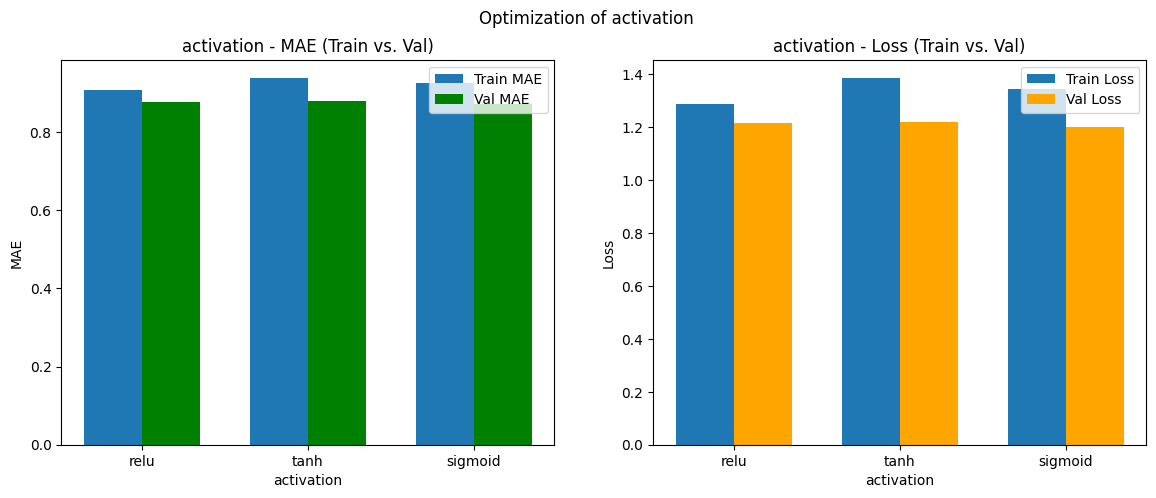

Best activation: sigmoid


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.001: train_mae = 0.9214, train_loss = 1.3342, val_mae = 0.8716, val_mse = 1.1987, test_mae = 0.8800


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.01: train_mae = 0.8857, train_loss = 1.2301, val_mae = 0.8848, val_mse = 1.2358, test_mae = 0.8947


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.1: train_mae = 1.0269, train_loss = 1.6614, val_mae = 0.9204, val_mse = 1.3316, test_mae = 0.9301


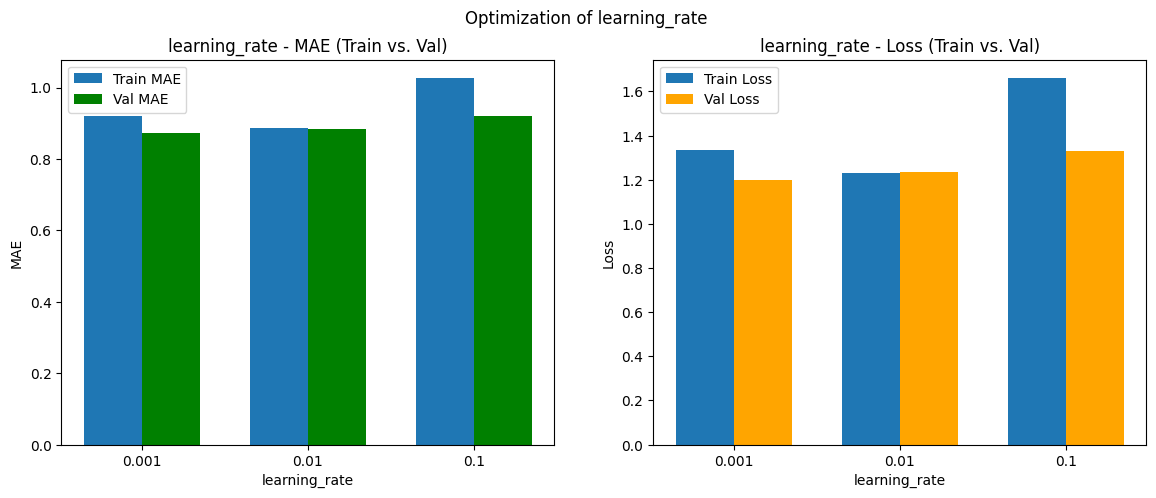

Best learning_rate: 0.001


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.0001: train_mae = 0.9343, train_loss = 1.4040, val_mae = 0.8751, val_loss = 1.2408, test_mae = 0.8809


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.001: train_mae = 0.9618, train_loss = 1.6079, val_mae = 0.8804, val_loss = 1.3837, test_mae = 0.8921


...

Candidate l1_0.0001_l2_0.1: train_mae = 1.3172, train_loss = 2.7905, val_mae = 1.2616, val_loss = 2.5740, test_mae = 1.2785


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.0001_l2_0.01: train_mae = 1.3232, train_loss = 2.8034, val_mae = 1.2634, val_loss = 2.5917, test_mae = 1.2813


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.0001_l2_0.001: train_mae = 1.3188, train_loss = 2.7955, val_mae = 1.2616, val_loss = 2.5709, test_mae = 1.2785


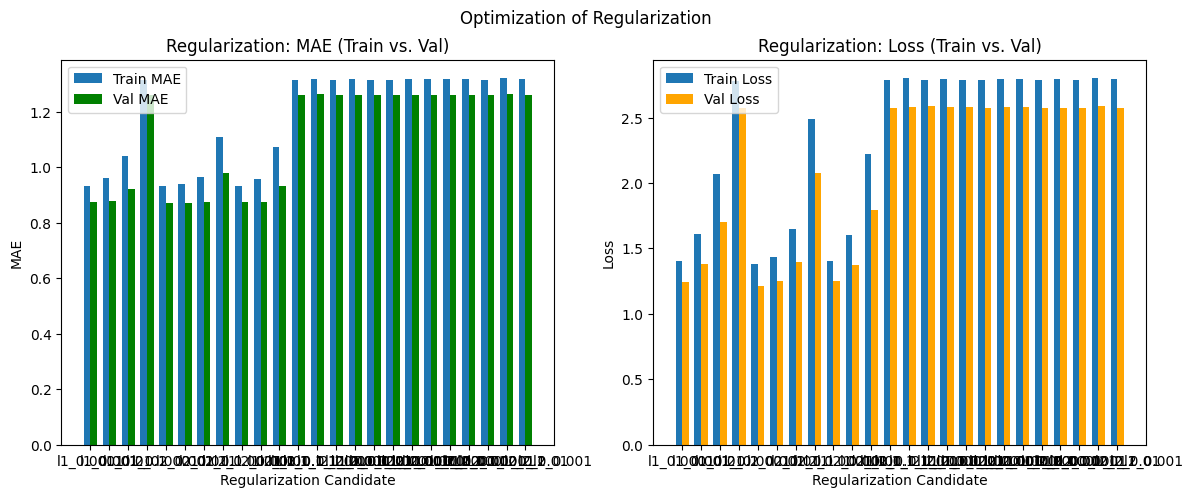

Temporal Best Hyperparameters: {'neurons': 64, 'layers': 2, 'activation': 'sigmoid', 'dropout_rate': 0.2, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x72295c4908f0>, 'batch_norm': False}
Selected Regularizer: l2_0.0001


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 8: train_mae = 0.9027, train_loss = 1.3017, val_mae = 0.8745, val_mse = 1.2270, test_mae = 0.8807


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 16: train_mae = 0.9070, train_loss = 1.3121, val_mae = 0.8829, val_mse = 1.2468, test_mae = 0.8933


...

Candidate 32: train_mae = 0.9321, train_loss = 1.3774, val_mae = 0.8791, val_mse = 1.2331, test_mae = 0.8869


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 64: train_mae = 0.9681, train_loss = 1.4814, val_mae = 0.8771, val_mse = 1.2249, test_mae = 0.8831


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 128: train_mae = 1.0130, train_loss = 1.6247, val_mae = 0.8722, val_mse = 1.2124, test_mae = 0.8791


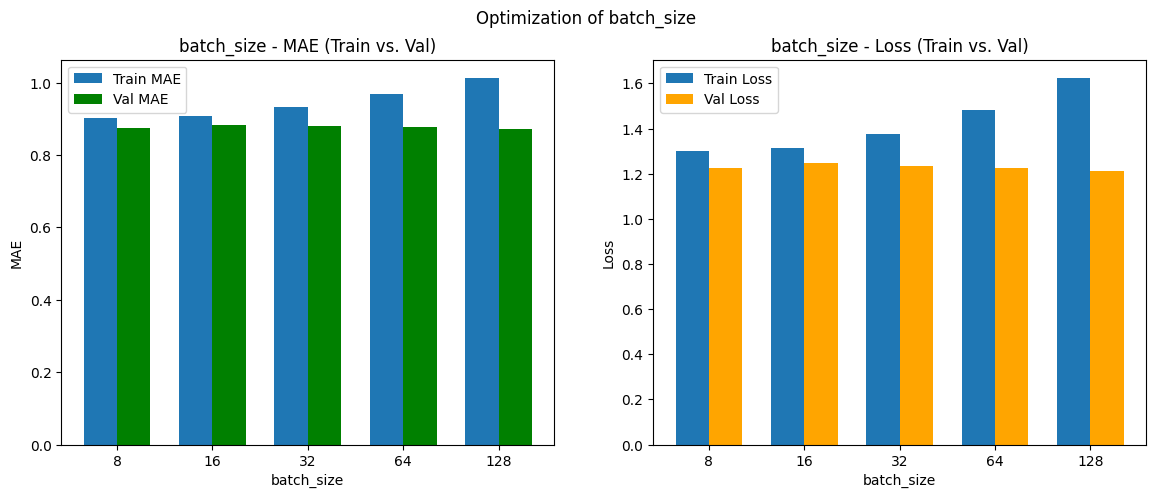

Best batch_size: 128


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate False: train_mae = 1.0201, train_loss = 1.6351, val_mae = 0.8718, val_mse = 1.2109, test_mae = 0.8787


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate True: train_mae = 1.0389, train_loss = 1.7004, val_mae = 0.8715, val_mse = 1.2033, test_mae = 0.8765


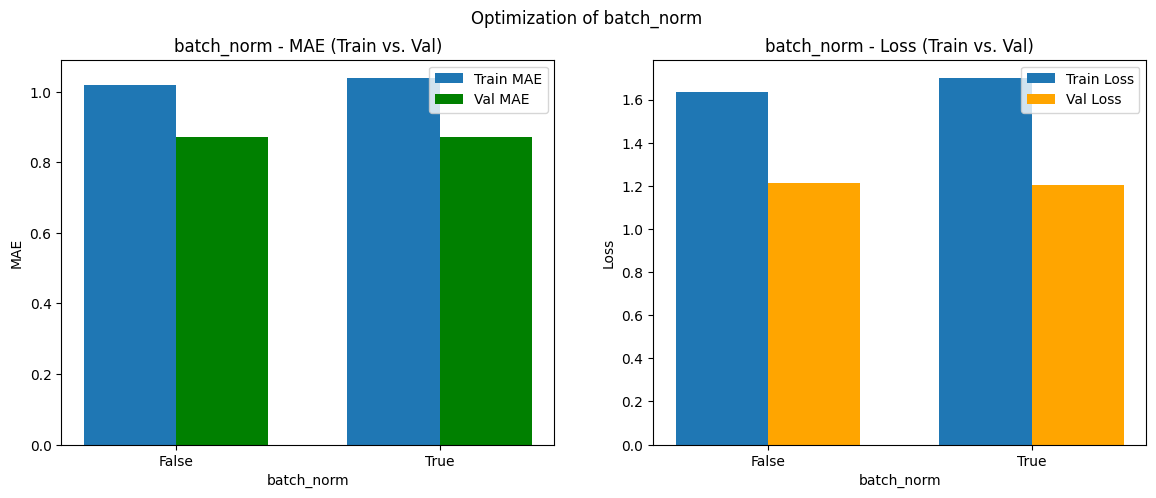

Best batch_norm: True


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 1: train_mae = 1.0310, train_loss = 1.6791, val_mae = 0.8707, val_mse = 1.1971, test_mae = 0.8782


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 2: train_mae = 1.0323, train_loss = 1.6835, val_mae = 0.8710, val_mse = 1.2017, test_mae = 0.8778


...

Candidate 3: train_mae = 1.0348, train_loss = 1.6992, val_mae = 0.8723, val_mse = 1.2094, test_mae = 0.8786


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 4: train_mae = 1.0425, train_loss = 1.7238, val_mae = 0.8733, val_mse = 1.2163, test_mae = 0.8821


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 5: train_mae = 1.0489, train_loss = 1.7549, val_mae = 0.8790, val_mse = 1.2335, test_mae = 0.8834


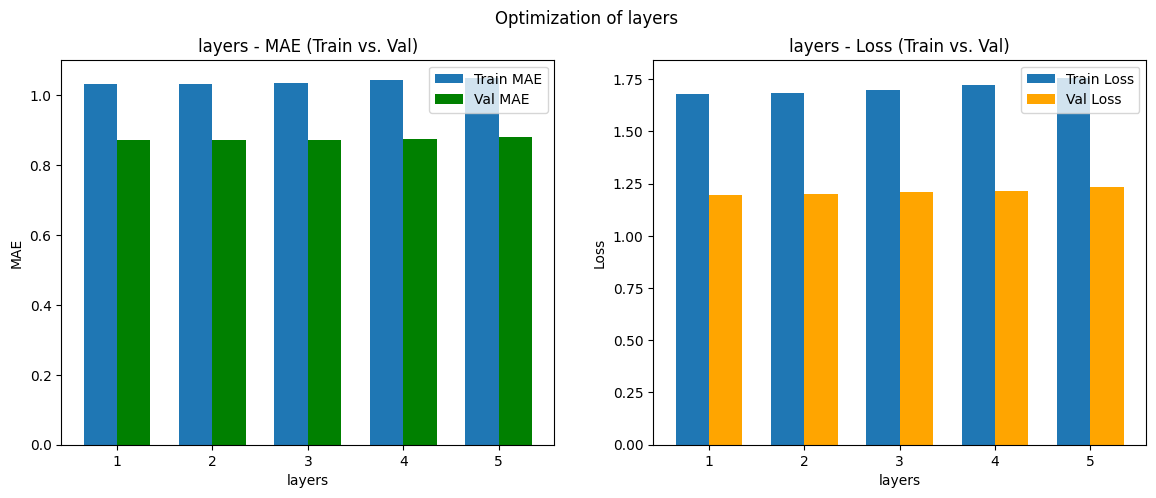

Best layers: 1


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 4: train_mae = 1.1910, train_loss = 2.2862, val_mae = 0.8975, val_mse = 1.2707, test_mae = 0.9073


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 8: train_mae = 1.1694, train_loss = 2.1665, val_mae = 0.8797, val_mse = 1.2202, test_mae = 0.8892


...

Candidate 128: train_mae = 0.9807, train_loss = 1.5133, val_mae = 0.8728, val_mse = 1.2044, test_mae = 0.8802


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 256: train_mae = 0.9356, train_loss = 1.3832, val_mae = 0.8721, val_mse = 1.2068, test_mae = 0.8786


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 512: train_mae = 0.9169, train_loss = 1.3268, val_mae = 0.8912, val_mse = 1.2603, test_mae = 0.8981


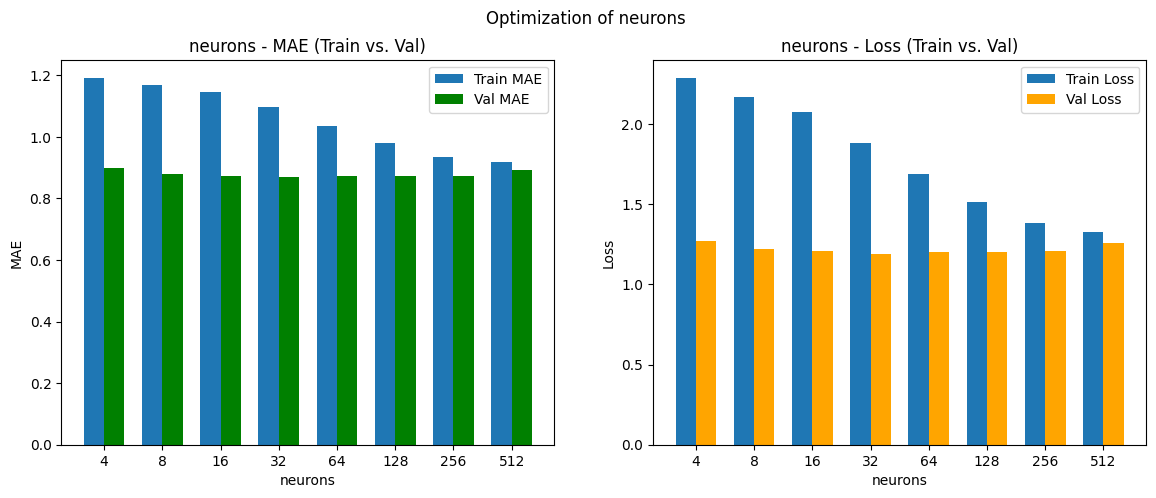

Best neurons: 32


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0: train_mae = 0.8861, train_loss = 1.2330, val_mae = 0.8796, val_mse = 1.2233, test_mae = 0.8890


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.1: train_mae = 1.0255, train_loss = 1.6475, val_mae = 0.8699, val_mse = 1.1975, test_mae = 0.8771


...

Candidate 0.3: train_mae = 1.1319, train_loss = 2.0202, val_mae = 0.8767, val_mse = 1.2145, test_mae = 0.8858


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.4: train_mae = 1.1463, train_loss = 2.0722, val_mae = 0.8768, val_mse = 1.2135, test_mae = 0.8837


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.5: train_mae = 1.1572, train_loss = 2.1288, val_mae = 0.8723, val_mse = 1.2026, test_mae = 0.8803


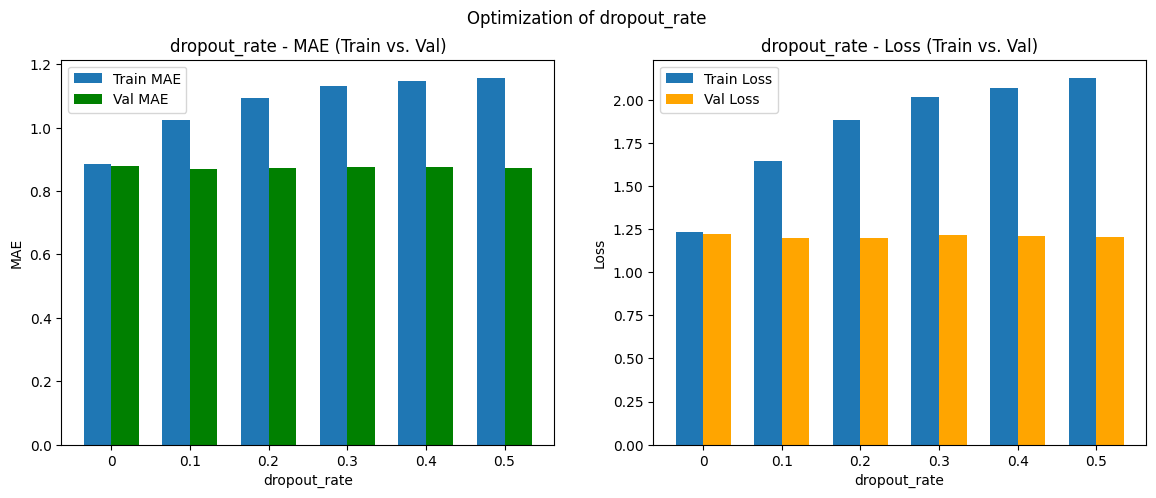

Best dropout_rate: 0.1


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate adam: train_mae = 1.0160, train_loss = 1.6336, val_mae = 0.8693, val_mse = 1.1931, test_mae = 0.8770


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate rmsprop: train_mae = 0.9921, train_loss = 1.5492, val_mae = 0.8752, val_mse = 1.2114, test_mae = 0.8836


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate sgd: train_mae = 1.0497, train_loss = 1.7355, val_mae = 0.8734, val_mse = 1.2039, test_mae = 0.8818


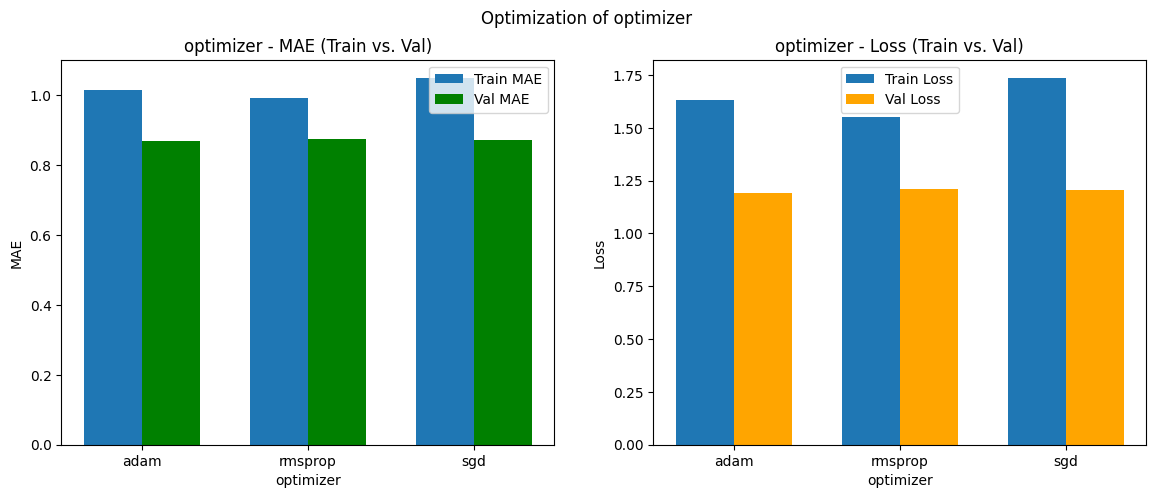

Best optimizer: adam


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final test MAE for order 1: 0.881284236907959

--- Order 2: ['batch_size', 'optimizer', 'layers', 'dropout_rate', 'learning_rate', 'neurons', 'activation', 'regularization', 'batch_norm'] ---


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 8: train_mae = 0.8903, train_loss = 1.2416, val_mae = 0.8872, val_mse = 1.2366, test_mae = 0.8968


...

Candidate 32: train_mae = 0.9048, train_loss = 1.2799, val_mae = 0.8802, val_mse = 1.2171, test_mae = 0.8918


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 64: train_mae = 0.9527, train_loss = 1.4259, val_mae = 0.8812, val_mse = 1.2182, test_mae = 0.8921


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 128: train_mae = 1.0411, train_loss = 1.7037, val_mae = 0.8741, val_mse = 1.2039, test_mae = 0.8840


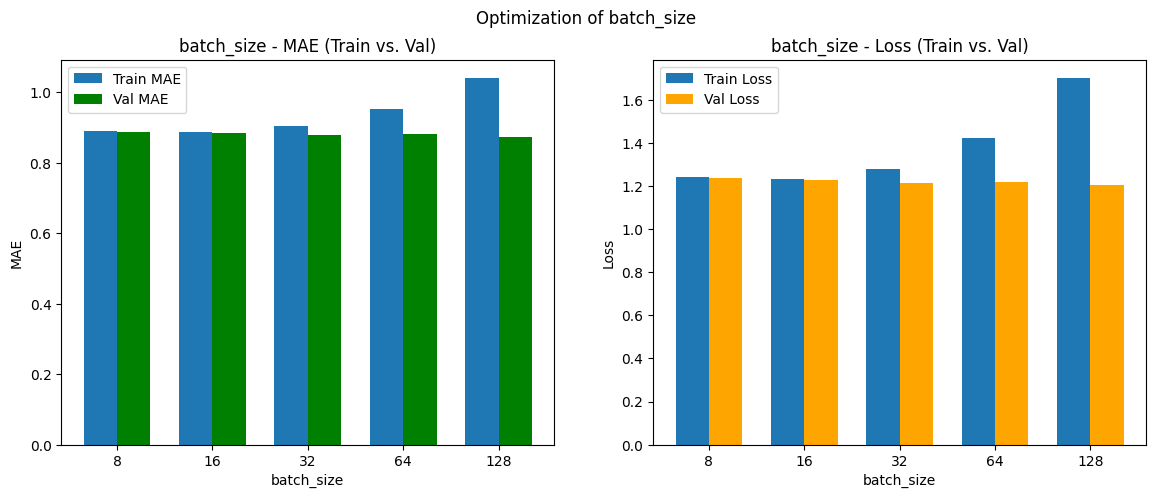

Best batch_size: 128


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate adam: train_mae = 1.0384, train_loss = 1.6926, val_mae = 0.8724, val_mse = 1.2020, test_mae = 0.8835


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate rmsprop: train_mae = 1.0088, train_loss = 1.5959, val_mae = 0.8854, val_mse = 1.2336, test_mae = 0.8961


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate sgd: train_mae = 1.0997, train_loss = 1.9053, val_mae = 0.8909, val_mse = 1.2518, test_mae = 0.9041


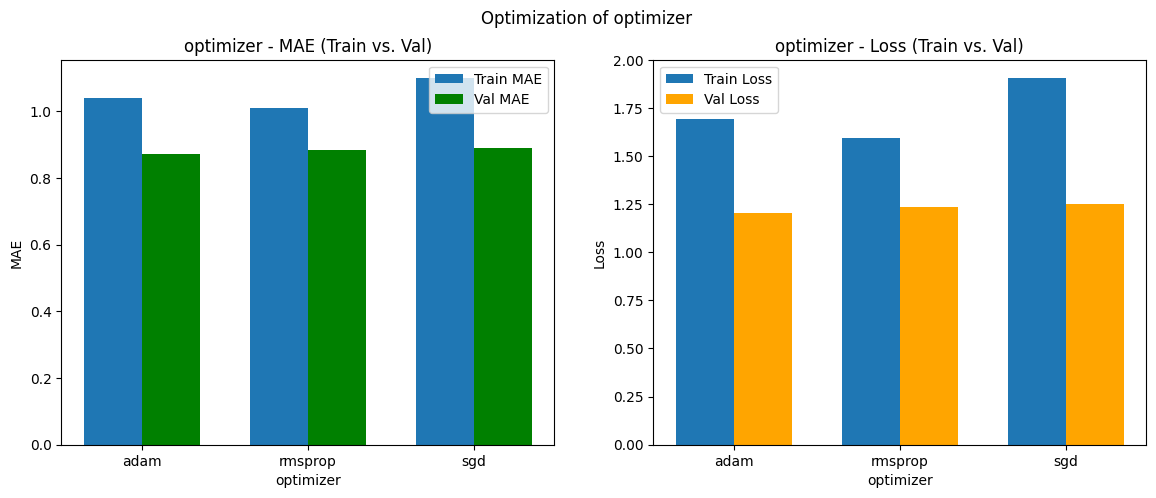

Best optimizer: adam


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 1: train_mae = 1.0392, train_loss = 1.6933, val_mae = 0.8750, val_mse = 1.2065, test_mae = 0.8811


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 2: train_mae = 1.0404, train_loss = 1.7043, val_mae = 0.8751, val_mse = 1.2054, test_mae = 0.8849


...

Candidate 3: train_mae = 1.0321, train_loss = 1.6803, val_mae = 0.8776, val_mse = 1.2162, test_mae = 0.8918


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 4: train_mae = 1.0503, train_loss = 1.7436, val_mae = 0.8829, val_mse = 1.2244, test_mae = 0.8939


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 5: train_mae = 1.0327, train_loss = 1.6826, val_mae = 0.8920, val_mse = 1.2536, test_mae = 0.9020


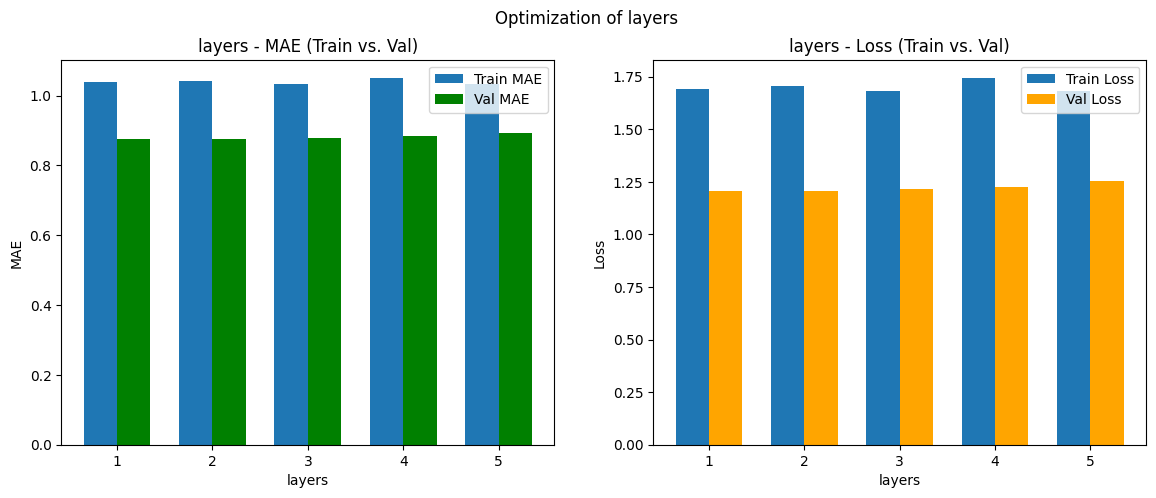

Best layers: 1


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0: train_mae = 0.8682, train_loss = 1.1807, val_mae = 0.8903, val_mse = 1.2484, test_mae = 0.8974


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.1: train_mae = 0.9897, train_loss = 1.5375, val_mae = 0.8820, val_mse = 1.2305, test_mae = 0.8895


...

Candidate 0.3: train_mae = 1.0701, train_loss = 1.7943, val_mae = 0.8847, val_mse = 1.2322, test_mae = 0.8948


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.4: train_mae = 1.0837, train_loss = 1.8506, val_mae = 0.8766, val_mse = 1.2128, test_mae = 0.8861


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.5: train_mae = 1.0924, train_loss = 1.8802, val_mae = 0.8803, val_mse = 1.2217, test_mae = 0.8887


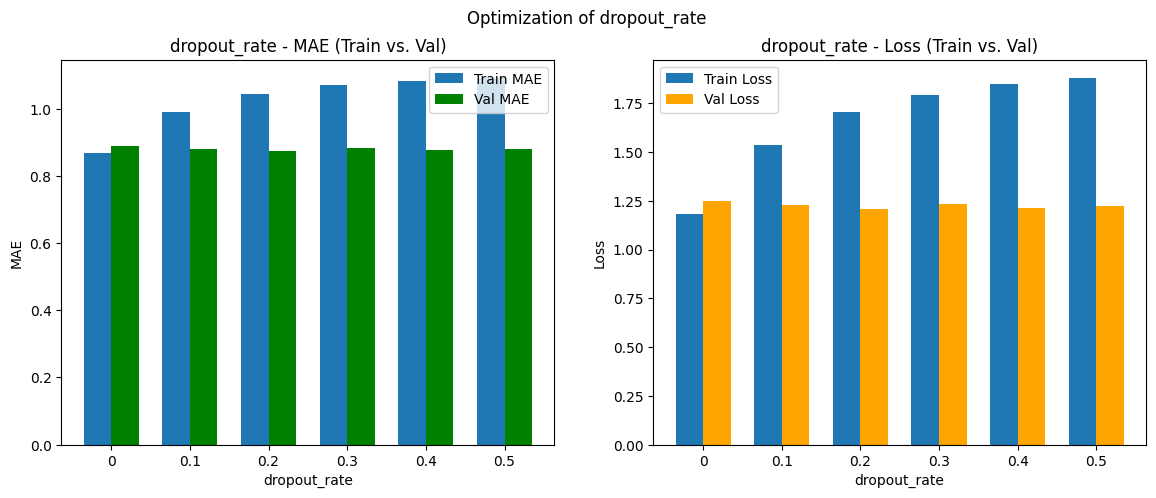

Best dropout_rate: 0.2


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.001: train_mae = 1.0395, train_loss = 1.6966, val_mae = 0.8779, val_mse = 1.2158, test_mae = 0.8880


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.01: train_mae = 0.8948, train_loss = 1.2583, val_mae = 0.8794, val_mse = 1.2195, test_mae = 0.8896


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.1: train_mae = 0.9636, train_loss = 1.4636, val_mae = 0.9202, val_mse = 1.3259, test_mae = 0.9327


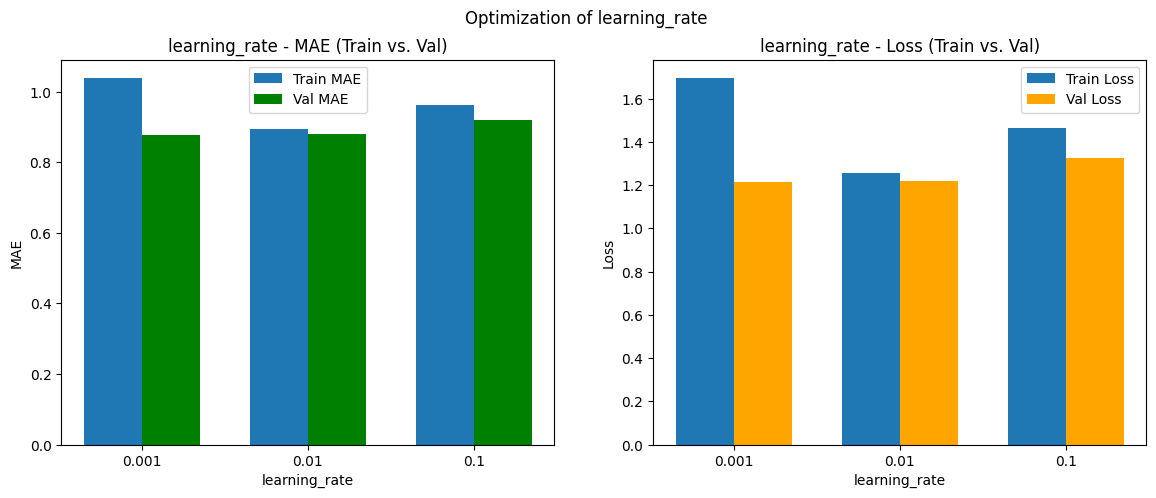

Best learning_rate: 0.001


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 4: train_mae = 1.1636, train_loss = 2.2524, val_mae = 0.9238, val_mse = 1.3440, test_mae = 0.9374


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 8: train_mae = 1.1033, train_loss = 1.9319, val_mae = 0.8824, val_mse = 1.2279, test_mae = 0.8925


...

Candidate 128: train_mae = 0.9920, train_loss = 1.5429, val_mae = 0.8743, val_mse = 1.2051, test_mae = 0.8827


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 256: train_mae = 0.9593, train_loss = 1.4443, val_mae = 0.8857, val_mse = 1.2368, test_mae = 0.8960


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 512: train_mae = 0.9297, train_loss = 1.3575, val_mae = 0.8826, val_mse = 1.2291, test_mae = 0.8904


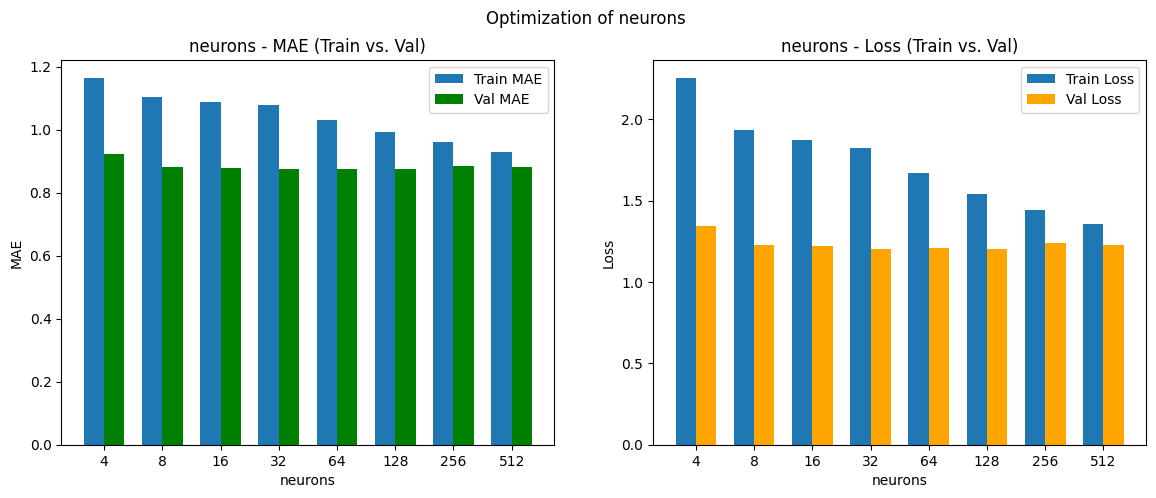

Best neurons: 32


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate relu: train_mae = 1.0701, train_loss = 1.8086, val_mae = 0.8772, val_mse = 1.2156, test_mae = 0.8859


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate tanh: train_mae = 1.0760, train_loss = 1.8193, val_mae = 0.8745, val_mse = 1.2018, test_mae = 0.8792


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate sigmoid: train_mae = 1.0748, train_loss = 1.8137, val_mae = 0.8748, val_mse = 1.2069, test_mae = 0.8801


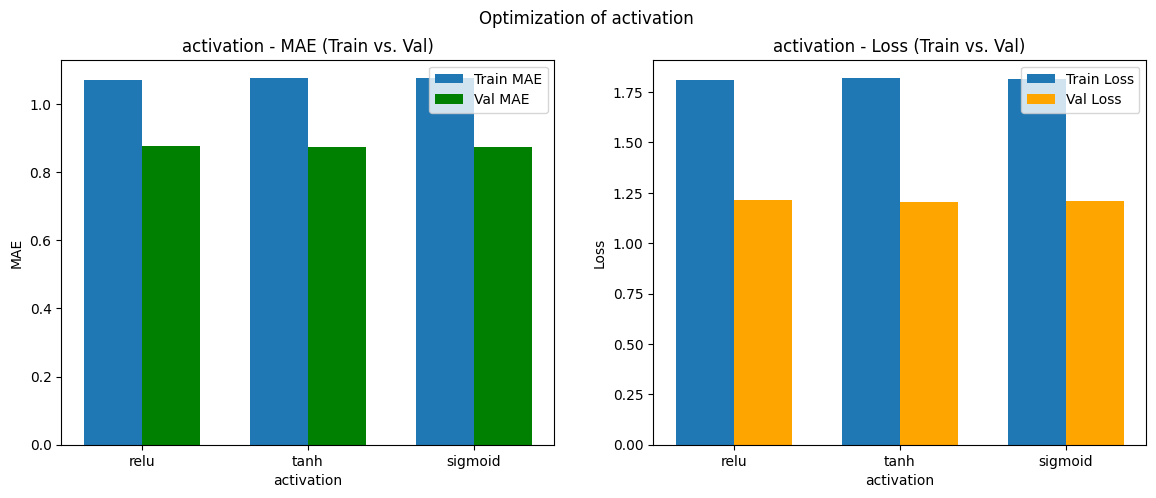

Best activation: tanh


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.0001: train_mae = 1.0743, train_loss = 1.8167, val_mae = 0.8781, val_loss = 1.2138, test_mae = 0.8824


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.001: train_mae = 1.0729, train_loss = 1.8222, val_mae = 0.8800, val_loss = 1.2255, test_mae = 0.8851


...

Candidate l1_0.0001_l2_0.1: train_mae = 1.0810, train_loss = 1.9969, val_mae = 0.8790, val_loss = 1.3761, test_mae = 0.8882


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.0001_l2_0.01: train_mae = 1.0844, train_loss = 1.9921, val_mae = 0.8769, val_loss = 1.3486, test_mae = 0.8843


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.0001_l2_0.001: train_mae = 1.0740, train_loss = 1.9681, val_mae = 0.8790, val_loss = 1.3722, test_mae = 0.8848


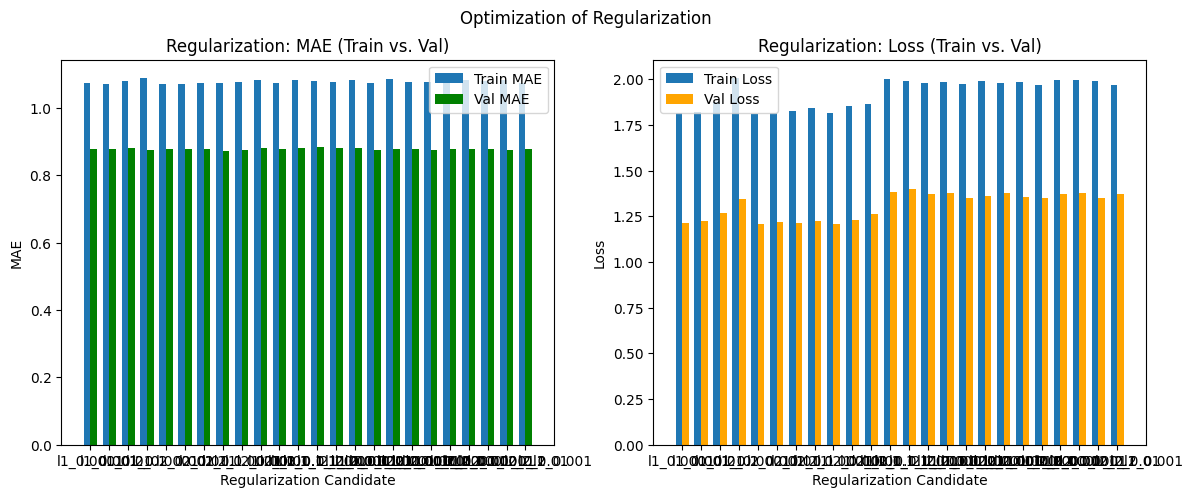

Temporal Best Hyperparameters: {'neurons': 32, 'layers': 1, 'activation': 'tanh', 'dropout_rate': 0.2, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 128, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x72295c31f380>, 'batch_norm': False}
Selected Regularizer: l2_0.1


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate False: train_mae = 1.0719, train_loss = 1.8381, val_mae = 0.8825, val_mse = 1.2438, test_mae = 0.8888


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate True: train_mae = 1.0954, train_loss = 1.9092, val_mae = 0.8750, val_mse = 1.2302, test_mae = 0.8809


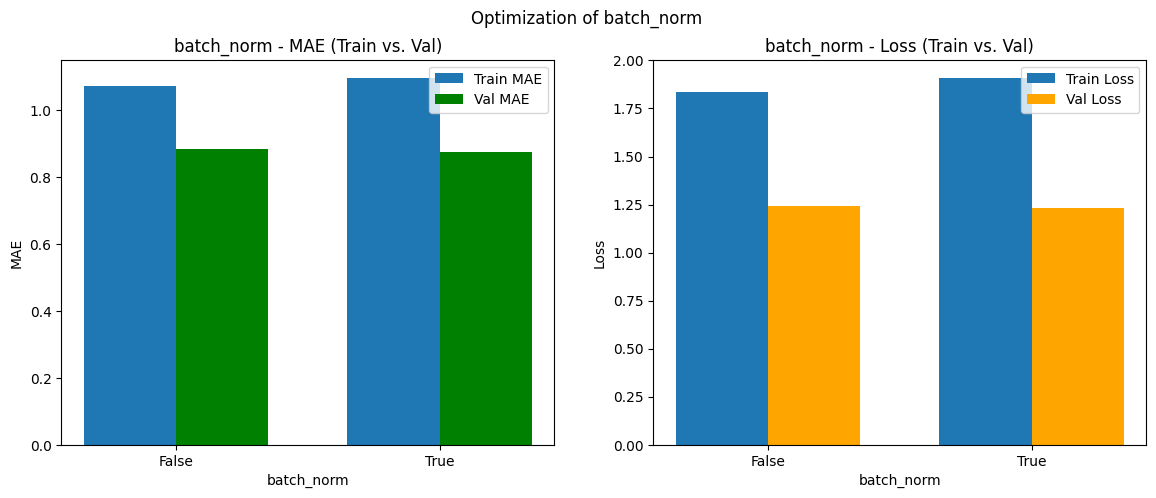

Best batch_norm: True


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final test MAE for order 2: 0.8785592913627625

--- Order 3: ['batch_norm', 'dropout_rate', 'neurons', 'activation', 'batch_size', 'learning_rate', 'regularization', 'optimizer', 'layers'] ---


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate False: train_mae = 0.9062, train_loss = 1.2857, val_mae = 0.8824, val_mse = 1.2231, test_mae = 0.8893


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate True: train_mae = 0.9587, train_loss = 1.4379, val_mae = 0.8825, val_mse = 1.2275, test_mae = 0.8896


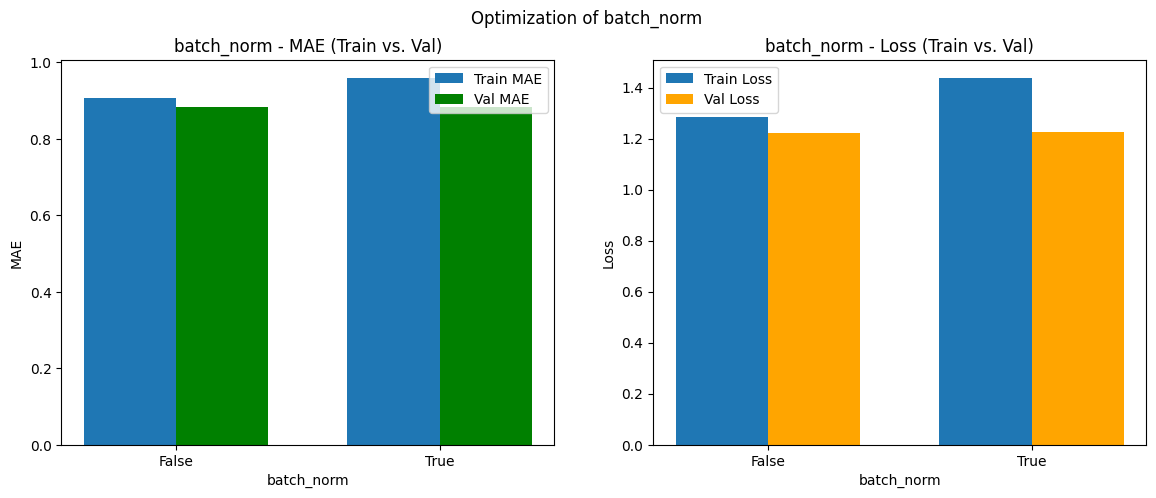

Best batch_norm: False


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0: train_mae = 0.8634, train_loss = 1.1694, val_mae = 0.9157, val_mse = 1.3141, test_mae = 0.9221


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.1: train_mae = 0.9198, train_loss = 1.3251, val_mae = 0.8798, val_mse = 1.2181, test_mae = 0.8884


...

Candidate 0.3: train_mae = 0.8990, train_loss = 1.2635, val_mae = 0.8992, val_mse = 1.2711, test_mae = 0.9048


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.4: train_mae = 0.9014, train_loss = 1.2736, val_mae = 0.8991, val_mse = 1.2752, test_mae = 0.9106


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.5: train_mae = 0.9202, train_loss = 1.3280, val_mae = 0.9016, val_mse = 1.2781, test_mae = 0.9128


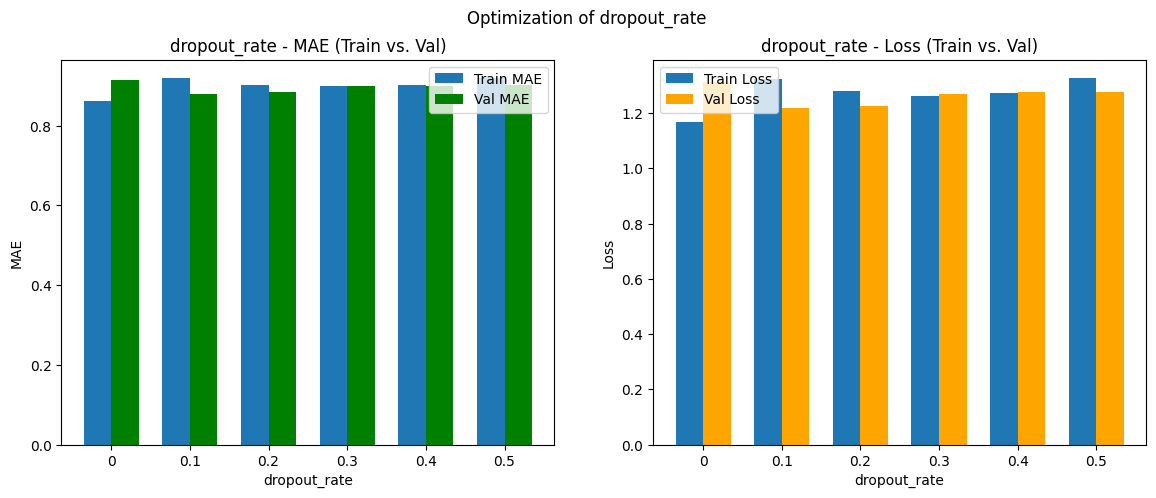

Best dropout_rate: 0.1


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 4: train_mae = 0.9558, train_loss = 1.4328, val_mae = 0.8945, val_mse = 1.2662, test_mae = 0.9073


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 8: train_mae = 0.9377, train_loss = 1.3812, val_mae = 0.8885, val_mse = 1.2455, test_mae = 0.9013


...

Candidate 128: train_mae = 0.9073, train_loss = 1.2948, val_mae = 0.8902, val_mse = 1.2456, test_mae = 0.8973


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 256: train_mae = 0.8778, train_loss = 1.2132, val_mae = 0.9093, val_mse = 1.3039, test_mae = 0.9158


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 512: train_mae = 0.8695, train_loss = 1.1843, val_mae = 0.9203, val_mse = 1.3404, test_mae = 0.9234


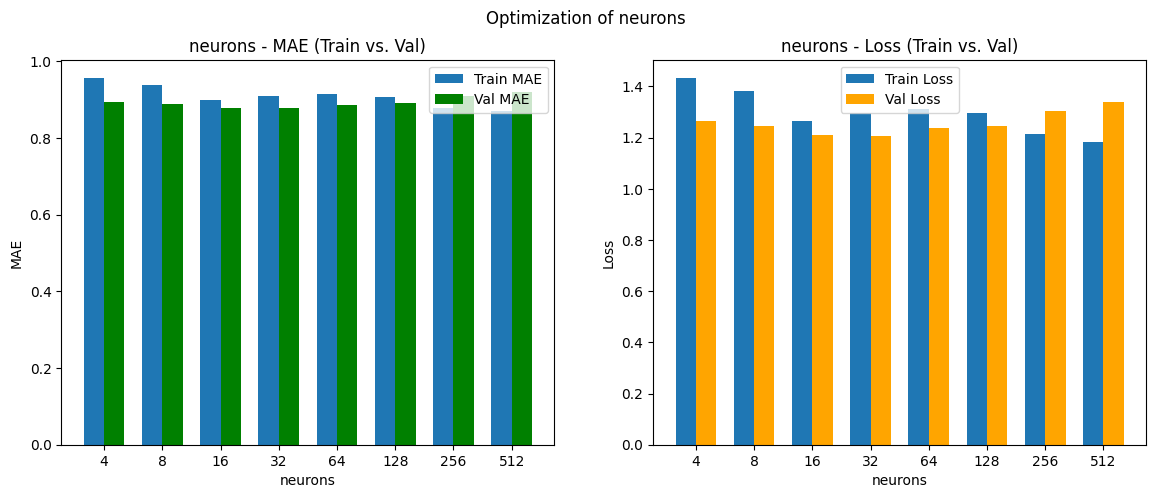

Best neurons: 32


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate relu: train_mae = 0.9072, train_loss = 1.2913, val_mae = 0.8793, val_mse = 1.2120, test_mae = 0.8884


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate tanh: train_mae = 0.9362, train_loss = 1.3759, val_mae = 0.8796, val_mse = 1.2189, test_mae = 0.8821


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate sigmoid: train_mae = 0.9253, train_loss = 1.3432, val_mae = 0.8753, val_mse = 1.2055, test_mae = 0.8813


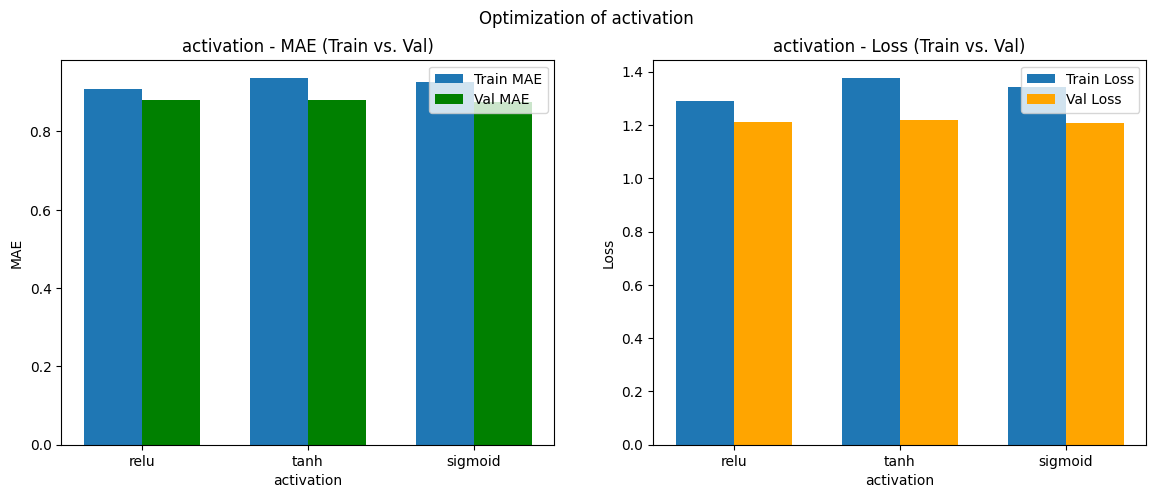

Best activation: sigmoid


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 8: train_mae = 0.8927, train_loss = 1.2497, val_mae = 0.8802, val_mse = 1.2194, test_mae = 0.8885


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 16: train_mae = 0.9037, train_loss = 1.2755, val_mae = 0.8815, val_mse = 1.2244, test_mae = 0.8882


...

Candidate 32: train_mae = 0.9265, train_loss = 1.3451, val_mae = 0.8708, val_mse = 1.1962, test_mae = 0.8767


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 64: train_mae = 0.9598, train_loss = 1.4488, val_mae = 0.8734, val_mse = 1.2025, test_mae = 0.8801


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 128: train_mae = 1.0086, train_loss = 1.5971, val_mae = 0.8751, val_mse = 1.2065, test_mae = 0.8814


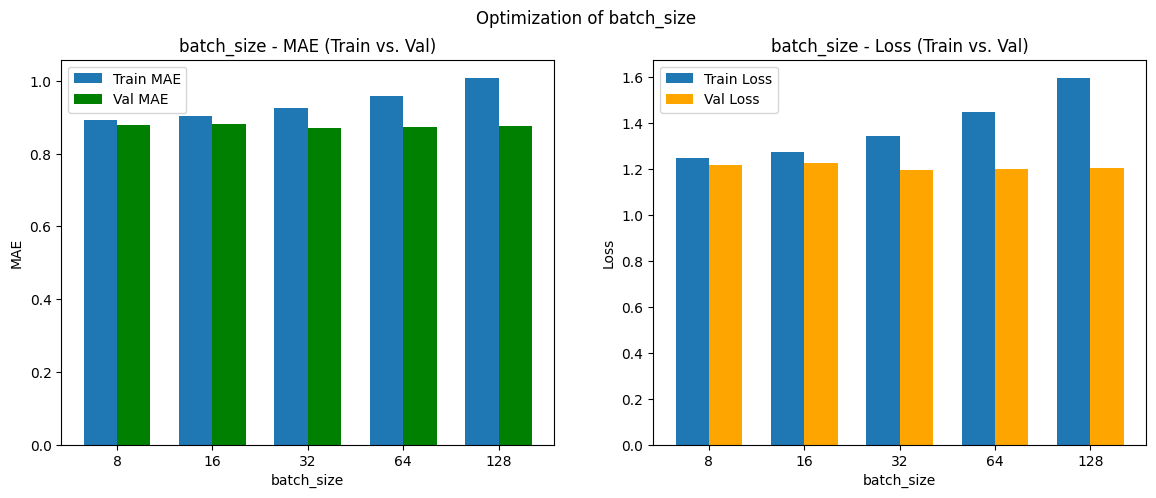

Best batch_size: 32


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.001: train_mae = 0.9249, train_loss = 1.3417, val_mae = 0.8762, val_mse = 1.2106, test_mae = 0.8846


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.01: train_mae = 0.8925, train_loss = 1.2482, val_mae = 0.8961, val_mse = 1.2636, test_mae = 0.9020


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 0.1: train_mae = 0.9513, train_loss = 1.4241, val_mae = 0.9295, val_mse = 1.3644, test_mae = 0.9399


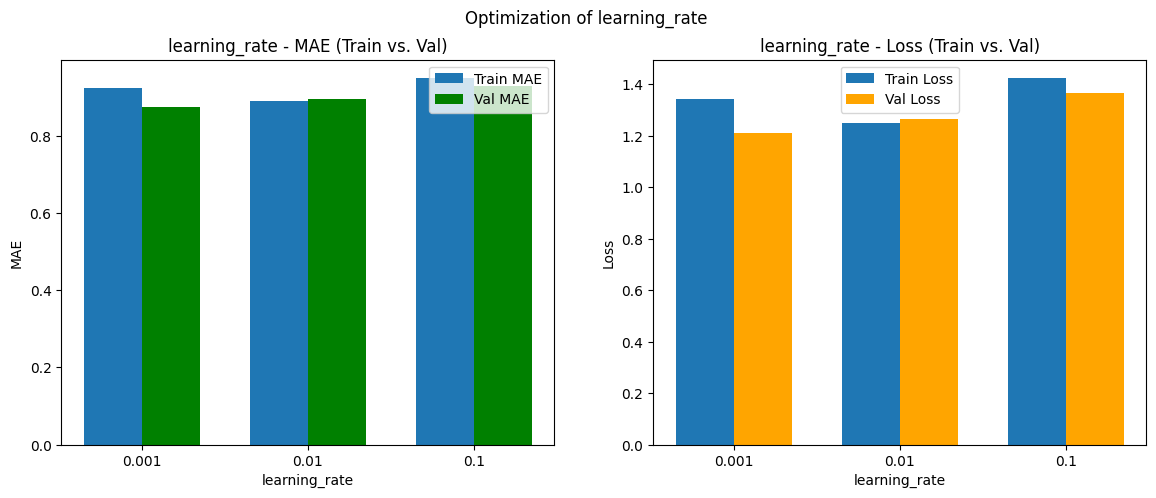

Best learning_rate: 0.001


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.0001: train_mae = 0.9286, train_loss = 1.3744, val_mae = 0.8725, val_loss = 1.2209, test_mae = 0.8792


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.001: train_mae = 0.9389, train_loss = 1.4801, val_mae = 0.8722, val_loss = 1.2937, test_mae = 0.8807


...

Candidate l1_0.0001_l2_0.1: train_mae = 1.3169, train_loss = 2.7408, val_mae = 1.2627, val_loss = 2.5419, test_mae = 1.2803


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.0001_l2_0.01: train_mae = 1.3155, train_loss = 2.7322, val_mae = 1.2616, val_loss = 2.5226, test_mae = 1.2785


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate l1_0.0001_l2_0.001: train_mae = 1.3184, train_loss = 2.7490, val_mae = 1.2624, val_loss = 2.5224, test_mae = 1.2789


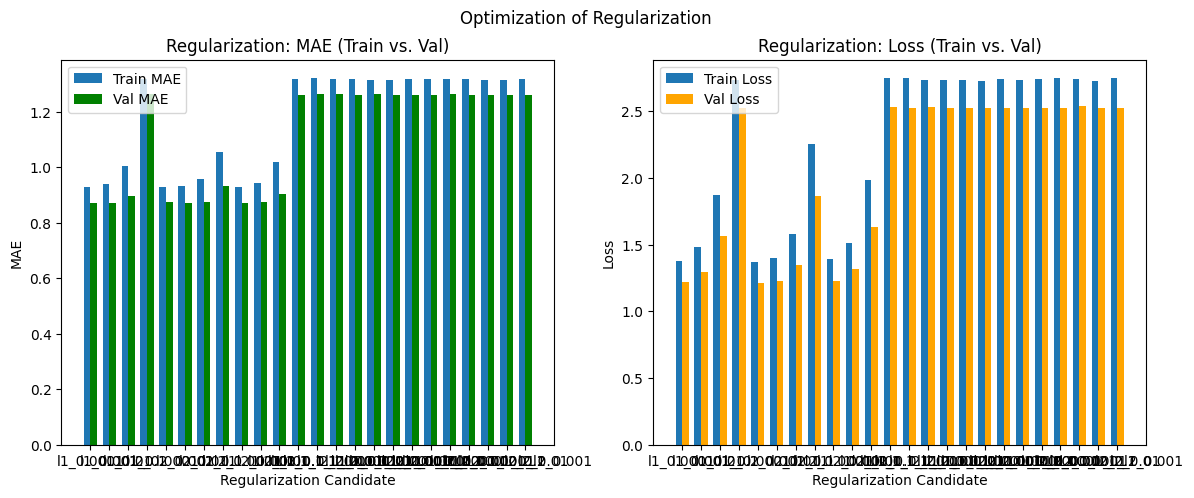

Temporal Best Hyperparameters: {'neurons': 32, 'layers': 2, 'activation': 'sigmoid', 'dropout_rate': 0.1, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x72295c31f200>, 'batch_norm': False}
Selected Regularizer: l2_0.001


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate adam: train_mae = 0.9346, train_loss = 1.4068, val_mae = 0.8721, val_mse = 1.2299, test_mae = 0.8806


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate rmsprop: train_mae = 0.9377, train_loss = 1.4105, val_mae = 0.8714, val_mse = 1.2308, test_mae = 0.8788


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate sgd: train_mae = 0.9922, train_loss = 1.6083, val_mae = 0.8749, val_mse = 1.2670, test_mae = 0.8847


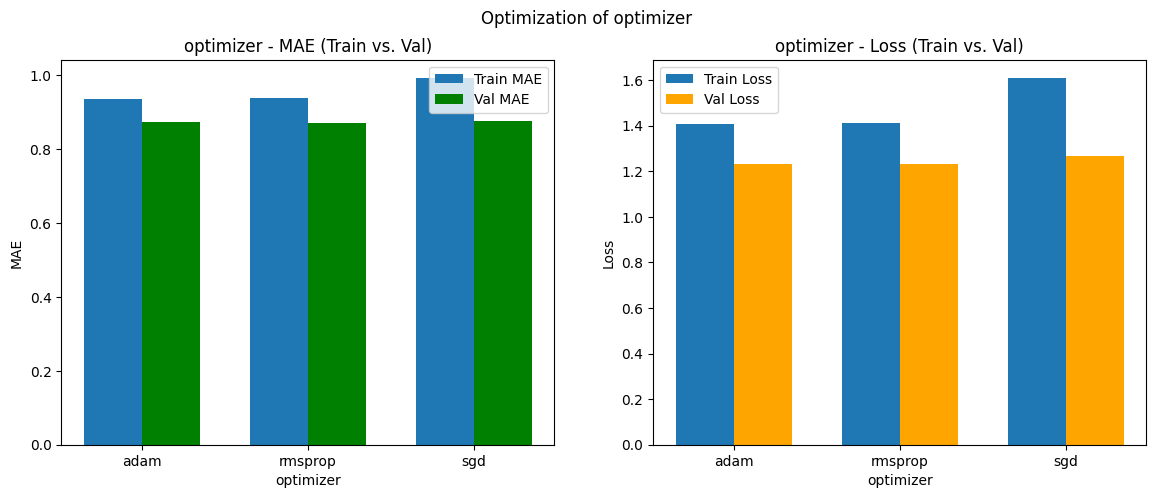

Best optimizer: rmsprop


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 1: train_mae = 0.9188, train_loss = 1.3370, val_mae = 0.8730, val_mse = 1.2075, test_mae = 0.8798


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 2: train_mae = 0.9313, train_loss = 1.3974, val_mae = 0.8764, val_mse = 1.2423, test_mae = 0.8831


...

Candidate 3: train_mae = 0.9441, train_loss = 1.4606, val_mae = 0.8807, val_mse = 1.2830, test_mae = 0.8909


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 4: train_mae = 0.9590, train_loss = 1.5330, val_mae = 0.8831, val_mse = 1.3221, test_mae = 0.8933


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Candidate 5: train_mae = 1.3161, train_loss = 2.7172, val_mae = 1.2616, val_mse = 2.5005, test_mae = 1.2786


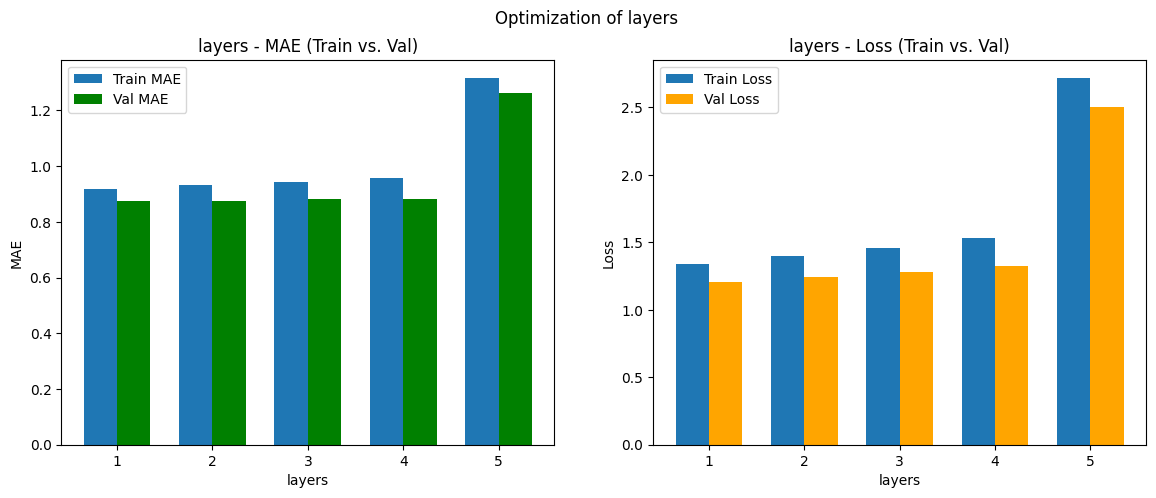

Best layers: 1


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final test MAE for order 3: 0.8738924860954285


In [85]:
# Number of orders to try (you could also use itertools.permutations if the list is small)
num_orders_to_try = 3
order_results = []

# Save the initial hyperparameters to be able to reset for each run.
initial_best_params = best_params_reg.copy()

for i in range(num_orders_to_try):
    # Randomly shuffle the order of optimization blocks.
    blocks_order = hyper_opt_blocks_reg.copy()
    random.shuffle(blocks_order)
    order_names = [block[0] for block in blocks_order]
    print(f"\n--- Order {i+1}: {order_names} ---")
    
    # Reset the best_params for this run.
    current_best_params = initial_best_params.copy()
    
    # Execute each optimization block in the chosen order.
    for (param_name, candidates, opt_func) in blocks_order:
        if param_name == "regularization":
            current_best_params = opt_func(candidates, current_best_params,
                                           build_and_train_regression, X_reg_val, y_reg_val, X_reg_test, y_reg_test,
                                           verbose=True)
        else:
            current_best_params = opt_func(param_name, candidates, current_best_params,
                                           build_and_train_regression, X_reg_val, y_reg_val, X_reg_test, y_reg_test,
                                           verbose=True)
    
    # After completing all blocks, build a final model and evaluate on the test set.
    final_model, _, _ = build_and_train_regression(**current_best_params)
    final_test_loss, final_test_mae = final_model.evaluate(X_reg_val, y_reg_val, verbose=0)
    print(f"Final test MAE for order {i+1}: {final_test_mae}")
    
    order_results.append((order_names, current_best_params.copy(), final_test_mae))



In [90]:
best_order_result = min(order_results, key=lambda x: x[2])
best_order_names, best_hyperparams, best_final_test_mae = best_order_result

print("\n=== Final Best Hyperparameters ===")
print("The best set of hyperparameters was found using the following order of optimization:")
print(best_order_names)
print("\nBest Hyperparameters:")
for key, value in best_hyperparams.items():
    print(f"  - {key}: {value}")
print(f"\nBest val MAE across all orders: {best_final_test_mae:.4f} LPA")

# Przebuduj model z najlepszymi hiperparametrami
best_model, _, _ = build_and_train_regression(**best_hyperparams)


# Użyj best_model zamiast final_model
y_reg_pred = best_model.predict(X_reg_test).flatten()
print(f"\n── WYNIKI REGRESJI ──────────────────────")
print(f"  MAE:  {mean_absolute_error(y_reg_test, y_reg_pred):.3f} LPA")
print(f"  RMSE: {root_mean_squared_error(y_reg_test, y_reg_pred):.3f} LPA")
print(f"  R²:   {r2_score(y_reg_test, y_reg_pred):.3f}")


=== Final Best Hyperparameters ===
The best set of hyperparameters was found using the following order of optimization:
['batch_norm', 'dropout_rate', 'neurons', 'activation', 'batch_size', 'learning_rate', 'regularization', 'optimizer', 'layers']

Best Hyperparameters:
  - neurons: 32
  - layers: 1
  - activation: sigmoid
  - dropout_rate: 0.1
  - optimizer: rmsprop
  - learning_rate: 0.001
  - batch_size: 32
  - regularization: <keras.src.regularizers.regularizers.L2 object at 0x72295c31f200>
  - batch_norm: False

Best val MAE across all orders: 0.8739 LPA


/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step

── WYNIKI REGRESJI ──────────────────────
  MAE:  0.881 LPA
  RMSE: 1.103 LPA
  R²:   0.525


256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


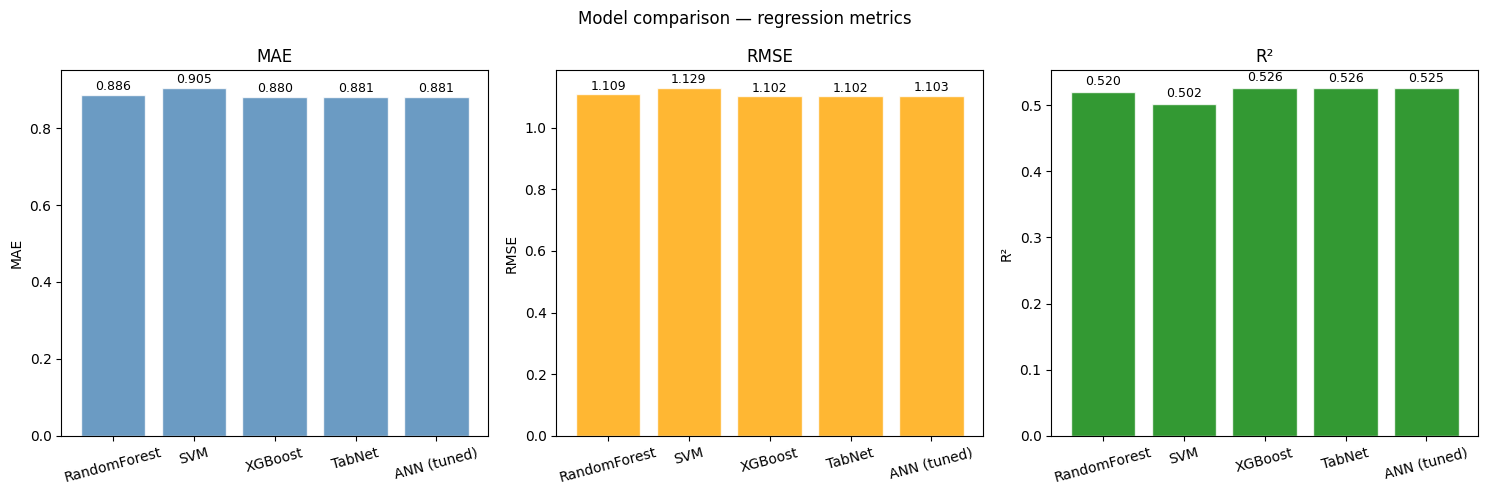

In [114]:
# Dodaj metryki ANN do results_reg przed rysowaniem wykresu
y_ann_pred = best_model.predict(X_reg_test).flatten()
results_reg["ANN (tuned)"] = {
    "MAE":  mean_absolute_error(y_reg_test, y_ann_pred),
    "RMSE": root_mean_squared_error(y_reg_test, y_ann_pred),
    "R²":   r2_score(y_reg_test, y_ann_pred)
}

results_df = pd.DataFrame(results_reg).T.astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'R²']
colors_bar = ['steelblue', 'orange', 'green']

for ax, metric, color in zip(axes, metrics, colors_bar):
    bars = ax.bar(results_df.index, results_df[metric], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model comparison — regression metrics')
plt.tight_layout()
plt.show()

Osiągnięte wyniki dla poszczególnych modeli są bardzo podobne.